In [5]:
#!/usr/bin/env python3
import re
import numpy as np
from numba import njit, prange
from multiprocessing import Pool, Process, Queue, cpu_count
from time import perf_counter
import numba

# ============================================================
# 1. TEXT PREP (MULTIPROCESS)
# ============================================================

TOKEN_RE = re.compile(r"[A-Za-z']+")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

def build_vocab(all_texts, min_freq=1):
    freq = {}
    for text in all_texts:
        for tok in tokenize(text):
            freq[tok] = freq.get(tok, 0) + 1
    itos = ["<PAD>", "<UNK>"]
    for tok, c in freq.items():
        if c >= min_freq:
            itos.append(tok)
    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos

def text_to_ids(text, stoi, sent_len):
    toks = tokenize(text)
    ids = [stoi.get(t, 1) for t in toks]  # 1 = UNK
    if len(ids) >= sent_len:
        return np.array(ids[:sent_len], dtype=np.int64)
    out = np.zeros(sent_len, dtype=np.int64)
    out[:len(ids)] = ids
    return out

def _prep_worker(args):
    shard_texts, shard_labels, stoi, sent_len = args
    X = np.zeros((len(shard_texts), sent_len), dtype=np.int64)
    y = np.array(shard_labels, dtype=np.int64)
    for i, txt in enumerate(shard_texts):
        X[i] = text_to_ids(txt, stoi, sent_len)
    return X, y

def parallel_prep(texts, labels, stoi, sent_len, n_procs=None):
    if n_procs is None:
        n_procs = cpu_count()
    n = len(texts)
    shard_size = (n + n_procs - 1) // n_procs
    args = []
    for p in range(n_procs):
        s = p * shard_size
        e = min(n, (n_procs, (p + 1) * shard_size)[1])
        e = min(n, (p + 1) * shard_size)
        if s >= e:
            break
        args.append((texts[s:e], labels[s:e], stoi, sent_len))
    with Pool(processes=len(args)) as pool:
        results = pool.map(_prep_worker, args)
    X_list, y_list = zip(*results)
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y

# ============================================================
# 2. CNN FORWARD ONLY (NUMBA PARALLEL)
# ============================================================

@njit(parallel=True)
def conv1d_forward_batch(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.zeros((B, C_out, L_out), dtype=np.float64)
    for b_idx in prange(B):  # parallelized over batch
        for co in range(C_out):
            for i in range(L_out):
                s = 0.0
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s + b[co]
    return out

@njit
def relu_forward(x):
    return np.maximum(x, 0.0)

@njit
def max_over_time_forward_batch(x):
    B, C_out, L_out = x.shape
    pooled = np.zeros((B, C_out), dtype=np.float64)
    for b_idx in range(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
            pooled[b_idx, co] = m
    return pooled

@njit
def linear_forward_batch(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.zeros((B, C), dtype=np.float64)
    for b_idx in range(B):
        for c in range(C):
            s = 0.0
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s + b[c]
    return out

@njit
def softmax_batch(logits):
    B, C = logits.shape
    out = np.zeros_like(logits)
    for b_idx in range(B):
        m = np.max(logits[b_idx])
        exps = np.exp(logits[b_idx] - m)
        s = np.sum(exps)
        out[b_idx] = exps / s
    return out

class TextCNNInference:
    def __init__(self, vocab_size, embed_dim,
                 num_filters, kernel_size,
                 num_classes, sent_len, seed=0):
        rng = np.random.default_rng(seed)

        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        self.sent_len = sent_len

        self.E = 0.01 * rng.standard_normal((vocab_size, embed_dim))
        self.W_conv = 0.01 * rng.standard_normal(
            (num_filters, kernel_size, embed_dim)
        )
        self.b_conv = np.zeros(num_filters, dtype=np.float64)
        self.L_out = sent_len - kernel_size + 1
        self.W_lin = 0.01 * rng.standard_normal(
            (num_classes, num_filters)
        )
        self.b_lin = np.zeros(num_classes, dtype=np.float64)

    def forward_batch_ids(self, X_ids):
        B, L = X_ids.shape
        x_emb = self.E[X_ids]          # (B, L, d)
        conv_z = conv1d_forward_batch(x_emb, self.W_conv, self.b_conv)
        relu_z = relu_forward(conv_z)
        pooled = max_over_time_forward_batch(relu_z)
        logits = linear_forward_batch(pooled, self.W_lin, self.b_lin)
        probs = softmax_batch(logits)
        return probs

    def predict_batch(self, X_ids):
        probs = self.forward_batch_ids(X_ids)
        return np.argmax(probs, axis=1)

# ============================================================
# 3. MULTIPROCESS INFERENCE
# ============================================================

def inference_worker(model_state, X_shard, out_q):
    vocab_size = model_state["E"].shape[0]
    embed_dim = model_state["E"].shape[1]
    num_filters = model_state["W_conv"].shape[0]
    kernel_size = model_state["W_conv"].shape[1]
    num_classes = model_state["W_lin"].shape[0]
    sent_len = X_shard.shape[1]

    model = TextCNNInference(
        vocab_size, embed_dim,
        num_filters, kernel_size,
        num_classes, sent_len
    )
    model.E = model_state["E"]
    model.W_conv = model_state["W_conv"]
    model.b_conv = model_state["b_conv"]
    model.W_lin = model_state["W_lin"]
    model.b_lin = model_state["b_lin"]

    preds = model.predict_batch(X_shard)
    out_q.put(preds)

def parallel_inference(model, X_ids, num_procs=None):
    if num_procs is None:
        num_procs = cpu_count()

    model_state = {
        "E": model.E,
        "W_conv": model.W_conv,
        "b_conv": model.b_conv,
        "W_lin": model.W_lin,
        "b_lin": model.b_lin,
    }

    N = X_ids.shape[0]
    shard_size = (N + num_procs - 1) // num_procs
    procs = []
    q = Queue()

    for p in range(num_procs):
        s = p * shard_size
        e = min(N, (p + 1) * shard_size)
        if s >= e:
            break
        shard = X_ids[s:e]
        proc = Process(target=inference_worker,
                       args=(model_state, shard, q))
        procs.append(proc)
        proc.start()

    preds_list = []
    for _ in range(len(procs)):
        preds_list.append(q.get())
    for proc in procs:
        proc.join()

    return np.concatenate(preds_list, axis=0)[:N]

# ============================================================
# 4. BENCH FULL PIPELINE (prep + parallel inference)
# ============================================================
 
def bench_full(num_procs=8, n_threads=1): #aytu
    numba.set_num_threads(n_threads)

    # Fake raw texts + labels
    texts = [
        "this movie was great and fun",
        "terrible plot and bad acting",
        "excellent film brilliant cast",
        "horrible film waste of time",
    ] * 50000  # 1M samples

    labels = [1, 0, 1, 0] * 50000  # unused

    sent_len = 16
    stoi, itos = build_vocab(texts, min_freq=1)

    # Prep: raw -> ID sequences (multiprocess)
    X_ids, y = parallel_prep(texts, labels, stoi, sent_len, n_procs=num_procs)

    vocab_size = len(itos)
    embed_dim = 32
    num_filters = 16
    kernel_size = 3
    num_classes = 2

    model = TextCNNInference(
        vocab_size, embed_dim,
        num_filters, kernel_size,
        num_classes, sent_len,
        seed=42
    )

    # Warmup: JIT conv etc. on a small batch
    _ = model.predict_batch(X_ids[:64])

    # Time full parallel inference over all samples
    t0 = perf_counter()
    preds = parallel_inference(model, X_ids, num_procs=num_procs)
    elapsed = perf_counter() - t0

    print(f"Pred shape: {preds.shape}")
    print(f"threads={n_threads}, procs={num_procs}, "
          f"inference time={elapsed:.2f} s")

# ============================================================
# 5. MAIN: run full benchmark at several thread counts
# ============================================================

# if __name__ == "__main__":
    # for t in [7,6,5,4]:
#         print(f"\n=== Numba threads = {t} ===")
#         t0 = perf_counter()
#         bench_full(num_procs=2, n_threads=t)
#         elapsed = perf_counter() - t0
#         print(f"wall time={elapsed:.2f} s")


In [ ]:
import numpy as np
from multiprocessing import Process, Queue, cpu_count
from time import perf_counter
#!/usr/bin/env python3
import re
import numpy as np
from numba import njit, prange
from multiprocessing import Pool, Process, Queue, cpu_count
from time import perf_counter
import numba

# ============================================================
# 1. TEXT PREP (MULTIPROCESS)
# ============================================================

# Simple whitespace + punctuation splitter
TOKEN_RE = re.compile(r"[A-Za-z']+")

def tokenize(text):
    return TOKEN_RE.findall(text.lower())

def build_vocab(all_texts, min_freq=1):
    freq = {}
    for text in all_texts:
        for tok in tokenize(text):
            freq[tok] = freq.get(tok, 0) + 1
    # reserve 0 for PAD, 1 for UNK
    itos = ["<PAD>", "<UNK>"]
    for tok, c in freq.items():
        if c >= min_freq:
            itos.append(tok)
    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos


def text_to_ids(text, stoi, sent_len):
    toks = tokenize(text)
    ids = [stoi.get(t, 1) for t in toks]  # 1 = UNK
    if len(ids) >= sent_len:
        return np.array(ids[:sent_len], dtype=np.int64)
    out = np.zeros(sent_len, dtype=np.int64)
    out[:len(ids)] = ids
    return out

def _prep_worker(args):
    shard_texts, shard_labels, stoi, sent_len = args
    X = np.zeros((len(shard_texts), sent_len), dtype=np.int64)
    y = np.array(shard_labels, dtype=np.int64)
    for i, txt in enumerate(shard_texts):
        X[i] = text_to_ids(txt, stoi, sent_len)
    return X, y

def parallel_prep(texts, labels, stoi, sent_len, n_procs=None):
    if n_procs is None:
        n_procs = cpu_count()
    n = len(texts)
    shard_size = (n + n_procs - 1) // n_procs
    args = []
    for p in range(n_procs):
        s = p * shard_size
        e = min(n, (p + 1) * shard_size)
        if s >= e:
            break
        args.append((texts[s:e], labels[s:e], stoi, sent_len))
    with Pool(processes=len(args)) as pool:
        results = pool.map(_prep_worker, args)
    X_list, y_list = zip(*results)
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y



def conv1d_forward_batch_numpy(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.zeros((B, C_out, L_out), dtype=np.float64)
    for b_idx in range(B):
        for co in range(C_out):
            for i in range(L_out):
                s = 0.0
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s + b[co]
    return out

def relu_forward(x):
    return np.maximum(x, 0.0)


def max_over_time_forward_batch(x):
    B, C_out, L_out = x.shape
    pooled = np.zeros((B, C_out), dtype=np.float64)
    for b_idx in range(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
            pooled[b_idx, co] = m
    return pooled

def linear_forward_batch(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.zeros((B, C), dtype=np.float64)
    for b_idx in range(B):
        for c in range(C):
            s = 0.0
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s + b[c]
    return out

def softmax_batch(logits):
    B, C = logits.shape
    out = np.zeros_like(logits)
    for b_idx in range(B):
        m = np.max(logits[b_idx])
        exps = np.exp(logits[b_idx] - m)
        s = np.sum(exps)
        out[b_idx] = exps / s
    return out

# class TextCNNPureNumpy:
    def __init__(self, vocab_size, embed_dim,
                 num_filters, kernel_size,
                 num_classes, sent_len, seed=0):
        rng = np.random.default_rng(seed)
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        self.sent_len = sent_len

        self.E = 0.01 * rng.standard_normal((vocab_size, embed_dim))
        self.W_conv = 0.01 * rng.standard_normal(
            (num_filters, kernel_size, embed_dim)
        )
        self.b_conv = np.zeros(num_filters, dtype=np.float64)
        self.L_out = sent_len - kernel_size + 1
        self.W_lin = 0.01 * rng.standard_normal(
            (num_classes, num_filters)
        )
        self.b_lin = np.zeros(num_classes, dtype=np.float64)

    def forward_batch_ids(self, X_ids):
        x_emb = self.E[X_ids]  # (B, L, d)
        conv_z = conv1d_forward_batch_numpy(x_emb, self.W_conv, self.b_conv)
        relu_z = relu_forward(conv_z)
        pooled = max_over_time_forward_batch(relu_z)
        logits = linear_forward_batch(pooled, self.W_lin, self.b_lin)
        probs = softmax_batch(logits)
        return probs

    def predict_batch(self, X_ids):
        probs = self.forward_batch_ids(X_ids)
        return np.argmax(probs, axis=1)

def inference_worker_numpy(model_state, X_shard, out_q):
    vocab_size = model_state["E"].shape[0]
    embed_dim = model_state["E"].shape[1]
    num_filters = model_state["W_conv"].shape[0]
    kernel_size = model_state["W_conv"].shape[1]
    num_classes = model_state["W_lin"].shape[0]
    sent_len = X_shard.shape[1]

    model = TextCNNPureNumpy(
        vocab_size, embed_dim,
        num_filters, kernel_size,
        num_classes, sent_len
    )
    # load weights
    model.E = model_state["E"]
    model.W_conv = model_state["W_conv"]
    model.b_conv = model_state["b_conv"]
    model.W_lin = model_state["W_lin"]
    model.b_lin = model_state["b_lin"]

    preds = model.predict_batch(X_shard)
    out_q.put(preds)

def parallel_inference_numpy(model, X_ids, num_procs):
    N = X_ids.shape[0]
    shard_size = (N + num_procs - 1) // num_procs

    model_state = {
        "E": model.E,
        "W_conv": model.W_conv,
        "b_conv": model.b_conv,
        "W_lin": model.W_lin,
        "b_lin": model.b_lin,
    }

    procs = []
    q = Queue()
    for p in range(num_procs):
        s = p * shard_size
        e = min(N, (p + 1) * shard_size)
        if s >= e:
            break
        shard = X_ids[s:e]
        proc = Process(target=inference_worker_numpy,
                       args=(model_state, shard, q))
        procs.append(proc)
        proc.start()

    preds_list = []
    for _ in range(len(procs)):
        preds_list.append(q.get())
    for proc in procs:
        proc.join()

    return np.concatenate(preds_list, axis=0)[:N]

def bench_data_parallel(num_samples=1_000_000,
                        num_procs_list=(1, 2, 4, 8)):
    rng = np.random.default_rng(0)
    sent_len = 16
    vocab_size = 5000
    embed_dim = 32
    num_filters = 16
    kernel_size = 3
    num_classes = 2

    X_ids = rng.integers(0, vocab_size,
                         size=(num_samples, sent_len),
                         dtype=np.int64)

    model = TextCNNPureNumpy(
        vocab_size, embed_dim,
        num_filters, kernel_size,
        num_classes, sent_len,
        seed=42
    )

    for p in num_procs_list:
        t0 = perf_counter()
        preds = parallel_inference_numpy(model, X_ids, num_procs=p)
        elapsed = perf_counter() - t0
        print(f"procs={p}, time={elapsed:.2f} s, preds.shape={preds.shape}")

# ============================================================
# 4. BENCH FULL PIPELINE (prep + parallel inference)
# ============================================================
 
def bench_full(num_procs=8, n_threads=1): #aytu
    numba.set_num_threads(n_threads)

    # Fake raw texts + labels
    texts = [
        "this movie was great and fun",
        "terrible plot and bad acting",
        "excellent film with a brilliant cast",
        "horrible film and a waste of time",
        "i loved the story and the ending",
        "the characters were boring and weak",
        "amazing soundtrack and strong performances",
        "this was dull, slow, and disappointing",
        "funny, charming, and surprisingly moving",
        "the script was messy and forgettable",
    ] * 100000

labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0] * 100000

    sent_len = 16
    stoi, itos = build_vocab(texts, min_freq=1)

    # Prep: raw -> ID sequences (multiprocess)
    X_ids, y = parallel_prep(texts, labels, stoi, sent_len, n_procs=num_procs)

    vocab_size = len(itos)
    embed_dim = 32
    num_filters = 16
    kernel_size = 3
    num_classes = 2

    model = TextCNNInference(
        vocab_size, embed_dim,
        num_filters, kernel_size,
        num_classes, sent_len,
        seed=42
    )

    # Warmup: JIT conv etc. on a small batch
    _ = model.predict_batch(X_ids[:64])

    # Time full parallel inference over all samples
    t0 = perf_counter()
    preds = parallel_inference(model, X_ids, num_procs=num_procs)
    elapsed = perf_counter() - t0

    print(f"Pred shape: {preds.shape}")
    print(f"threads={n_threads}, procs={num_procs}, "
          f"inference time={elapsed:.2f} s")
    return preds
    
if __name__ == "__main__":
    for t in [8,6,4,2,1]:
        print(f"\n=== Number of Procs = {t} ===")
        t0 = perf_counter()
        results1 = bench_full(num_procs=t, n_threads=1)
        elapsed = perf_counter() - t0
        print(f"wall time={elapsed:.2f} s")  ## this is working



=== Number of Procs = 8 ===
Pred shape: (1000000,)
threads=1, procs=8, inference time=10.42 s
wall time=15.03 s

=== Number of Procs = 6 ===
Pred shape: (1000000,)
threads=1, procs=6, inference time=11.52 s
wall time=13.83 s

=== Number of Procs = 4 ===
Pred shape: (1000000,)
threads=1, procs=4, inference time=16.68 s
wall time=19.19 s

=== Number of Procs = 2 ===
Pred shape: (1000000,)
threads=1, procs=2, inference time=30.97 s
wall time=34.13 s

=== Number of Procs = 1 ===
Pred shape: (1000000,)
threads=1, procs=1, inference time=61.26 s
wall time=65.49 s


In [7]:
#!/usr/bin/env python3
import numpy as np
from time import perf_counter
from numba import njit, prange, set_num_threads, get_num_threads


# ============================================================
# Numba kernels
# ============================================================

@njit(parallel=True)
def embed_lookup(E, X_ids):
    B, L = X_ids.shape
    d = E.shape[1]
    out = np.empty((B, L, d), dtype=E.dtype)
    for b in prange(B):
        for i in range(L):
            idx = X_ids[b, i]
            for j in range(d):
                out[b, i, j] = E[idx, j]
    return out


@njit(parallel=True)
def conv1d_forward_batch(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.empty((B, C_out, L_out), dtype=x_batch.dtype)

    for b_idx in prange(B):
        for co in range(C_out):
            bias = b[co]
            for i in range(L_out):
                s = bias
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s
    return out


@njit(parallel=True)
def relu3d_inplace(x):
    B, C, L = x.shape
    for b in prange(B):
        for c in range(C):
            for i in range(L):
                if x[b, c, i] < 0.0:
                    x[b, c, i] = 0.0


@njit(parallel=True)
def max_over_time_forward_batch(x):
    B, C_out, L_out = x.shape
    pooled = np.empty((B, C_out), dtype=x.dtype)

    for b_idx in prange(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
            pooled[b_idx, co] = m
    return pooled


@njit(parallel=True)
def linear_forward_batch(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.empty((B, C), dtype=x.dtype)

    for b_idx in prange(B):
        for c in range(C):
            s = b[c]
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s
    return out


@njit(parallel=True)
def softmax_batch(logits):
    B, C = logits.shape
    out = np.empty_like(logits)

    for b_idx in prange(B):
        m = logits[b_idx, 0]
        for c in range(1, C):
            if logits[b_idx, c] > m:
                m = logits[b_idx, c]

        s = 0.0
        for c in range(C):
            out[b_idx, c] = np.exp(logits[b_idx, c] - m)
            s += out[b_idx, c]

        for c in range(C):
            out[b_idx, c] /= s

    return out


@njit(parallel=True)
def argmax_batch(probs):
    B, C = probs.shape
    preds = np.empty(B, dtype=np.int64)

    for b_idx in prange(B):
        best_idx = 0
        best_val = probs[b_idx, 0]
        for c in range(1, C):
            if probs[b_idx, c] > best_val:
                best_val = probs[b_idx, c]
                best_idx = c
        preds[b_idx] = best_idx

    return preds


# ============================================================
# Model
# ============================================================

class TextCNNNumba:
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size,
                 num_classes, sent_len, seed=42, dtype=np.float32):
        rng = np.random.default_rng(seed)
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        self.sent_len = sent_len
        self.dtype = dtype

        self.E = (0.01 * rng.standard_normal((vocab_size, embed_dim))).astype(dtype)
        self.W_conv = (0.01 * rng.standard_normal(
            (num_filters, kernel_size, embed_dim)
        )).astype(dtype)
        self.b_conv = np.zeros(num_filters, dtype=dtype)

        self.W_lin = (0.01 * rng.standard_normal(
            (num_classes, num_filters)
        )).astype(dtype)
        self.b_lin = np.zeros(num_classes, dtype=dtype)

    def forward_batch_ids(self, X_ids):
        x_emb = embed_lookup(self.E, X_ids)
        conv_z = conv1d_forward_batch(x_emb, self.W_conv, self.b_conv)
        relu3d_inplace(conv_z)
        pooled = max_over_time_forward_batch(conv_z)
        logits = linear_forward_batch(pooled, self.W_lin, self.b_lin)
        probs = softmax_batch(logits)
        return probs

    def predict_batch(self, X_ids):
        probs = self.forward_batch_ids(X_ids)
        return argmax_batch(probs)

    def predict_dataset(self, X_ids, batch_size=4096):
        N = X_ids.shape[0]
        preds = np.empty(N, dtype=np.int64)
        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            preds[s:e] = self.predict_batch(X_ids[s:e])
        return preds


# ============================================================
# Benchmark
# ============================================================

def benchmark_threads(num_samples=500_000,
                      sent_len=16,
                      vocab_size=5000,
                      embed_dim=32,
                      num_filters=32,
                      kernel_size=3,
                      num_classes=2,
                      batch_size=4096,
                      threads_list=(1, 2, 4, 8),
                      repeats=3,
                      warmup_samples=8192):
    rng = np.random.default_rng(0)

    X_ids = rng.integers(
        0, vocab_size,
        size=(num_samples, sent_len),
        dtype=np.int64
    )

    model = TextCNNNumba(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_size=kernel_size,
        num_classes=num_classes,
        sent_len=sent_len,
        seed=42,
        dtype=np.float32
    )

    warm_n = min(warmup_samples, num_samples)
    X_warm = X_ids[:warm_n]

    # --------------------------------------------------------
    # Global compile warmup at 1 thread
    # --------------------------------------------------------
    set_num_threads(1)
    t0 = perf_counter()
    _ = model.predict_dataset(X_warm, batch_size=min(batch_size, warm_n))
    compile_warmup_sec = perf_counter() - t0

    # --------------------------------------------------------
    # Reference output for correctness
    # --------------------------------------------------------
    set_num_threads(1)
    _ = model.predict_dataset(X_warm, batch_size=min(batch_size, warm_n))
    t0 = perf_counter()
    ref_preds = model.predict_dataset(X_ids, batch_size=batch_size)
    ref_time = perf_counter() - t0

    results = []

    print("=" * 98)
    print(f"num_samples={num_samples}, sent_len={sent_len}, embed_dim={embed_dim}, "
        f"num_filters={num_filters}, batch_size={batch_size}")
    print(f"global warmup/compile time = {compile_warmup_sec:.3f} s")
    print(f"reference 1-thread full pass = {ref_time:.3f} s")
    print("=" * 98)

    for t in threads_list:
        set_num_threads(t)

        # per-thread untimed warmup
        t_warm0 = perf_counter()
        _ = model.predict_dataset(X_warm, batch_size=min(batch_size, warm_n))
        thread_warmup_sec = perf_counter() - t_warm0

        times = []
        last_preds = None

        for _ in range(repeats):
            t0 = perf_counter()
            preds = model.predict_dataset(X_ids, batch_size=batch_size)
            elapsed = perf_counter() - t0
            times.append(elapsed)
            last_preds = preds

        best_time = min(times)
        avg_time = sum(times) / len(times)
        same_preds = np.array_equal(last_preds, ref_preds)
        speedup = ref_time / best_time
        efficiency = speedup / t

        row = {
            "threads": t,
            "thread_warmup_sec": thread_warmup_sec,
            "best_time_sec": best_time,
            "avg_time_sec": avg_time,
            "speedup_vs_1thread": speedup,
            "efficiency": efficiency,
            "same_preds_as_1thread": same_preds,
            "runtime_threads": get_num_threads(),
        }
        results.append(row)

        print(
            f"threads={t:>2d} | "
            f"warmup={thread_warmup_sec:>7.3f}s | "
            f"best={best_time:>8.3f}s | "
            f"avg={avg_time:>8.3f}s | "
            f"speedup={speedup:>6.2f}x | "
            f"eff={efficiency:>5.2f} | "
            f"same_preds={same_preds}"
        )

    return results


if __name__ == "__main__":
    benchmark_threads(
        num_samples=500_000,
        sent_len=16,
        vocab_size=5000,
        embed_dim=32,
        num_filters=32,
        kernel_size=3,
        num_classes=2,
        batch_size=4096,
        threads_list=(2, 4, 6, 8),
        repeats=1,
        warmup_samples=8192,
    )


num_samples=500000, sent_len=16, embed_dim=32, num_filters=32, batch_size=4096
global warmup/compile time = 5.087 s
reference 1-thread full pass = 15.261 s
threads= 2 | warmup=  0.128s | best=   7.796s | avg=   7.796s | speedup=  1.96x | eff= 0.98 | same_preds=True
threads= 4 | warmup=  0.077s | best=   4.168s | avg=   4.168s | speedup=  3.66x | eff= 0.92 | same_preds=True
threads= 6 | warmup=  0.074s | best=   3.318s | avg=   3.318s | speedup=  4.60x | eff= 0.77 | same_preds=True
threads= 8 | warmup=  0.040s | best=   2.946s | avg=   2.946s | speedup=  5.18x | eff= 0.65 | same_preds=True


In [12]:
#!/usr/bin/env python3
import re
import numpy as np
from time import perf_counter
from collections import Counter
from numba import njit, prange, set_num_threads, get_num_threads


# ============================================================
# Text preprocessing
# ============================================================

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

def tokenize(text):
    text = text.lower()
    return re.findall(r"[a-z']+", text)

def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, freq in counter.items():
        if freq >= min_freq:
            stoi[token] = len(stoi)

    itos = [None] * len(stoi)
    for token, idx in stoi.items():
        itos[idx] = token
    return stoi, itos

def encode_text(text, stoi, sent_len):
    toks = tokenize(text)
    ids = [stoi.get(tok, stoi[UNK_TOKEN]) for tok in toks[:sent_len]]
    if len(ids) < sent_len:
        ids.extend([stoi[PAD_TOKEN]] * (sent_len - len(ids)))
    return ids

def encode_texts(texts, stoi, sent_len):
    X_ids = np.array([encode_text(t, stoi, sent_len) for t in texts], dtype=np.int64)
    return X_ids

def build_dataset(base_texts, base_labels, repeat_factor, sent_len, min_freq=1):
    texts = base_texts * repeat_factor
    labels = np.array(base_labels * repeat_factor, dtype=np.int64)
    stoi, itos = build_vocab(texts, min_freq=min_freq)
    X_ids = encode_texts(texts, stoi, sent_len)
    return texts, labels, stoi, itos, X_ids


# ============================================================
# Numba kernels
# ============================================================

@njit(parallel=True)
def embed_lookup(E, X_ids):
    B, L = X_ids.shape
    d = E.shape[1]
    out = np.empty((B, L, d), dtype=E.dtype)
    for b in prange(B):
        for i in range(L):
            idx = X_ids[b, i]
            for j in range(d):
                out[b, i, j] = E[idx, j]
    return out

@njit(parallel=True)
def conv1d_forward_batch(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.empty((B, C_out, L_out), dtype=x_batch.dtype)

    for b_idx in prange(B):
        for co in range(C_out):
            bias = b[co]
            for i in range(L_out):
                s = bias
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s
    return out

@njit(parallel=True)
def relu3d_inplace(x):
    B, C, L = x.shape
    for b in prange(B):
        for c in range(C):
            for i in range(L):
                if x[b, c, i] < 0.0:
                    x[b, c, i] = 0.0

@njit(parallel=True)
def max_over_time_forward_batch(x):
    B, C_out, L_out = x.shape
    pooled = np.empty((B, C_out), dtype=x.dtype)

    for b_idx in prange(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
            pooled[b_idx, co] = m
    return pooled

@njit(parallel=True)
def linear_forward_batch(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.empty((B, C), dtype=x.dtype)

    for b_idx in prange(B):
        for c in range(C):
            s = b[c]
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s
    return out

@njit(parallel=True)
def softmax_batch(logits):
    B, C = logits.shape
    out = np.empty_like(logits)

    for b_idx in prange(B):
        m = logits[b_idx, 0]
        for c in range(1, C):
            if logits[b_idx, c] > m:
                m = logits[b_idx, c]

        s = 0.0
        for c in range(C):
            out[b_idx, c] = np.exp(logits[b_idx, c] - m)
            s += out[b_idx, c]

        for c in range(C):
            out[b_idx, c] /= s

    return out

@njit(parallel=True)
def argmax_batch(probs):
    B, C = probs.shape
    preds = np.empty(B, dtype=np.int64)

    for b_idx in prange(B):
        best_idx = 0
        best_val = probs[b_idx, 0]
        for c in range(1, C):
            if probs[b_idx, c] > best_val:
                best_val = probs[b_idx, c]
                best_idx = c
        preds[b_idx] = best_idx

    return preds


# ============================================================
# Model
# ============================================================

class TextCNNNumba:
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size,
                 num_classes, sent_len, seed=42, dtype=np.float32):
        rng = np.random.default_rng(seed)
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        self.sent_len = sent_len
        self.dtype = dtype

        self.E = (0.01 * rng.standard_normal((vocab_size, embed_dim))).astype(dtype)
        self.W_conv = (0.01 * rng.standard_normal(
            (num_filters, kernel_size, embed_dim)
        )).astype(dtype)
        self.b_conv = np.zeros(num_filters, dtype=dtype)

        self.W_lin = (0.01 * rng.standard_normal(
            (num_classes, num_filters)
        )).astype(dtype)
        self.b_lin = np.zeros(num_classes, dtype=dtype)

    def forward_batch_ids(self, X_ids):
        x_emb = embed_lookup(self.E, X_ids)
        conv_z = conv1d_forward_batch(x_emb, self.W_conv, self.b_conv)
        relu3d_inplace(conv_z)
        pooled = max_over_time_forward_batch(conv_z)
        logits = linear_forward_batch(pooled, self.W_lin, self.b_lin)
        probs = softmax_batch(logits)
        return probs

    def predict_batch(self, X_ids):
        probs = self.forward_batch_ids(X_ids)
        return argmax_batch(probs)

    def predict_dataset(self, X_ids, batch_size=4096):
        N = X_ids.shape[0]
        preds = np.empty(N, dtype=np.int64)
        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            preds[s:e] = self.predict_batch(X_ids[s:e])
        return preds


# ============================================================
# Benchmark on real texts
# ============================================================

def benchmark_real_text(
    base_texts,
    base_labels,
    repeat_factor=50000,
    sent_len=16,
    embed_dim=32,
    num_filters=32,
    kernel_size=3,
    num_classes=2,
    batch_size=4096,
    threads_list=(1, 2, 4, 8),
    repeats=1,
    warmup_samples=8192,
    seed=42,
):
    t_setup0 = perf_counter()
    texts, labels, stoi, itos, X_ids = build_dataset(
        base_texts, base_labels, repeat_factor, sent_len, min_freq=1
    )
    setup_data_sec = perf_counter() - t_setup0

    vocab_size = len(itos)
    t_model0 = perf_counter()
    model = TextCNNNumba(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_size=kernel_size,
        num_classes=num_classes,
        sent_len=sent_len,
        seed=seed,
        dtype=np.float32,
    )
    model_init_sec = perf_counter() - t_model0
    
    print(f"dataset build time = {setup_data_sec:.3f} s")
    print(f"model init time    = {model_init_sec:.3f} s")
    
    warm_n = min(warmup_samples, X_ids.shape[0])
    X_warm = X_ids[:warm_n]

    set_num_threads(1)
    t0 = perf_counter()
    _ = model.predict_dataset(X_warm, batch_size=min(batch_size, warm_n))
    compile_warmup_sec = perf_counter() - t0

    set_num_threads(1)
    _ = model.predict_dataset(X_warm, batch_size=min(batch_size, warm_n))
    t0 = perf_counter()
    ref_preds = model.predict_dataset(X_ids, batch_size=batch_size)
    ref_time = perf_counter() - t0

    print("=" * 100)
    print(f"num_samples={len(texts)}, vocab_size={vocab_size}, sent_len={sent_len}, "
          f"embed_dim={embed_dim}, num_filters={num_filters}, batch_size={batch_size}")
    print(f"global warmup/compile time = {compile_warmup_sec:.3f} s")
    print(f"reference 1-thread full pass = {ref_time:.3f} s")
    print("=" * 100)

    print("sample vocab entries:")
    shown = min(12, len(itos))
    for i in range(shown):
        print(f"  {i:2d} -> {itos[i]}")

    print("\nfirst 3 encoded samples:")
    for i in range(min(3, len(texts))):
        print(f"text   : {texts[i]}")
        print(f"label  : {labels[i]}")
        print(f"tokenids: {X_ids[i].tolist()}")

    results = []
    for t in threads_list:
        set_num_threads(t)

        t_warm0 = perf_counter()
        _ = model.predict_dataset(X_warm, batch_size=min(batch_size, warm_n))
        thread_warmup_sec = perf_counter() - t_warm0

        times = []
        last_preds = None

        for _ in range(repeats):
            t0 = perf_counter()
            preds = model.predict_dataset(X_ids, batch_size=batch_size)
            elapsed = perf_counter() - t0
            times.append(elapsed)
            last_preds = preds

        best_time = min(times)
        avg_time = sum(times) / len(times)
        same_preds = np.array_equal(last_preds, ref_preds)
        speedup = ref_time / best_time
        efficiency = speedup / t

        row = {
            "threads": t,
            "thread_warmup_sec": thread_warmup_sec,
            "best_time_sec": best_time,
            "avg_time_sec": avg_time,
            "speedup_vs_1thread": speedup,
            "efficiency": efficiency,
            "same_preds_as_1thread": same_preds,
            "runtime_threads": get_num_threads(),
        }
        results.append(row)

        print(
            f"threads={t:>2d} | "
            f"warmup={thread_warmup_sec:>7.3f}s | "
            f"best={best_time:>8.3f}s | "
            f"avg={avg_time:>8.3f}s | "
            f"speedup={speedup:>6.2f}x | "
            f"eff={efficiency:>5.2f} | "
            f"same_preds={same_preds}"
        )

    return {
        "texts": texts,
        "labels": labels,
        "stoi": stoi,
        "itos": itos,
        "X_ids": X_ids,
        "results": results,
    }


if __name__ == "__main__":
    import os
    nthreads = int(os.environ.get("SLURM_CPUS_PER_TASK", "1"))
    set_num_threads(nthreads)

    base_texts = [
        "this movie was great and fun",
        "terrible plot and bad acting",
        "excellent film with a brilliant cast",
        "horrible film and a waste of time",
        "i loved the story and the ending",
        "the characters were boring and weak",
        "amazing soundtrack and strong performances",
        "this was dull slow and disappointing",
        "funny charming and surprisingly moving",
        "the script was messy and forgettable",
    ]

    base_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

    benchmark_real_text(
        base_texts=base_texts,
        base_labels=base_labels,
        repeat_factor=50000,   # 10 * 50000 = 500,000 samples
        sent_len=16,
        embed_dim=32,
        num_filters=32,
        kernel_size=3,
        num_classes=2,
        batch_size=4096,
        threads_list=(2, 4, 8),
        repeats=1,
        warmup_samples=8192,
        seed=42,
    )


dataset build time = 3.251 s
model init time    = 0.001 s
num_samples=500000, vocab_size=45, sent_len=16, embed_dim=32, num_filters=32, batch_size=4096
global warmup/compile time = 4.268 s
reference 1-thread full pass = 14.657 s
sample vocab entries:
   0 -> <pad>
   1 -> <unk>
   2 -> this
   3 -> movie
   4 -> was
   5 -> great
   6 -> and
   7 -> fun
   8 -> terrible
   9 -> plot
  10 -> bad
  11 -> acting

first 3 encoded samples:
text   : this movie was great and fun
label  : 1
tokenids: [2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text   : terrible plot and bad acting
label  : 0
tokenids: [8, 9, 6, 10, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text   : excellent film with a brilliant cast
label  : 1
tokenids: [12, 13, 14, 15, 16, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
threads= 2 | warmup=  0.115s | best=   7.485s | avg=   7.485s | speedup=  1.96x | eff= 0.98 | same_preds=True
threads= 4 | warmup=  0.070s | best=   4.264s | avg=   4.264s | speedup=  3.44x | eff= 0.86 | same_preds=True
t

In [15]:
benchmark_real_text(
    base_texts=base_texts,
    base_labels=base_labels,
    repeat_factor=50000,   # 10 * 50000 = 500,000 samples
    sent_len=16,
    embed_dim=32,
    num_filters=32,
    kernel_size=3,
    num_classes=2,
    batch_size=4096,
    threads_list=( 4,8),
    repeats=1,
    warmup_samples=8192,
    seed=42,
)

dataset build time = 2.893 s
model init time    = 0.000 s
num_samples=500000, vocab_size=45, sent_len=16, embed_dim=32, num_filters=32, batch_size=4096
global warmup/compile time = 0.245 s
reference 1-thread full pass = 14.867 s
sample vocab entries:
   0 -> <pad>
   1 -> <unk>
   2 -> this
   3 -> movie
   4 -> was
   5 -> great
   6 -> and
   7 -> fun
   8 -> terrible
   9 -> plot
  10 -> bad
  11 -> acting

first 3 encoded samples:
text   : this movie was great and fun
label  : 1
tokenids: [2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text   : terrible plot and bad acting
label  : 0
tokenids: [8, 9, 6, 10, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text   : excellent film with a brilliant cast
label  : 1
tokenids: [12, 13, 14, 15, 16, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
threads= 4 | warmup=  0.066s | best=   4.157s | avg=   4.157s | speedup=  3.58x | eff= 0.89 | same_preds=True
threads= 8 | warmup=  0.041s | best=   2.467s | avg=   2.467s | speedup=  6.03x | eff= 0.75 | same_preds=True


{'texts': ['this movie was great and fun',
  'terrible plot and bad acting',
  'excellent film with a brilliant cast',
  'horrible film and a waste of time',
  'i loved the story and the ending',
  'the characters were boring and weak',
  'amazing soundtrack and strong performances',
  'this was dull slow and disappointing',
  'funny charming and surprisingly moving',
  'the script was messy and forgettable',
  'this movie was great and fun',
  'terrible plot and bad acting',
  'excellent film with a brilliant cast',
  'horrible film and a waste of time',
  'i loved the story and the ending',
  'the characters were boring and weak',
  'amazing soundtrack and strong performances',
  'this was dull slow and disappointing',
  'funny charming and surprisingly moving',
  'the script was messy and forgettable',
  'this movie was great and fun',
  'terrible plot and bad acting',
  'excellent film with a brilliant cast',
  'horrible film and a waste of time',
  'i loved the story and the endin

In [16]:
#!/usr/bin/env python3
import os
import re
import numpy as np
from time import perf_counter
from collections import Counter
from numba import njit, prange, set_num_threads, get_num_threads


# ============================================================
# Text preprocessing
# ============================================================

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

def tokenize(text):
    text = text.lower()
    return re.findall(r"[a-z']+", text)

def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, freq in counter.items():
        if freq >= min_freq:
            stoi[token] = len(stoi)

    itos = [None] * len(stoi)
    for token, idx in stoi.items():
        itos[idx] = token
    return stoi, itos

def encode_text(text, stoi, sent_len):
    toks = tokenize(text)
    ids = [stoi.get(tok, stoi[UNK_TOKEN]) for tok in toks[:sent_len]]
    if len(ids) < sent_len:
        ids.extend([stoi[PAD_TOKEN]] * (sent_len - len(ids)))
    return ids

def encode_texts(texts, stoi, sent_len):
    return np.array([encode_text(t, stoi, sent_len) for t in texts], dtype=np.int64)

def build_dataset(base_texts, base_labels, repeat_factor, sent_len, min_freq=1):
    texts = base_texts * repeat_factor
    labels = np.array(base_labels * repeat_factor, dtype=np.int64)
    stoi, itos = build_vocab(texts, min_freq=min_freq)
    X_ids = encode_texts(texts, stoi, sent_len)
    return texts, labels, stoi, itos, X_ids


# ============================================================
# Numba kernels
# ============================================================

@njit(parallel=True)
def embed_lookup(E, X_ids):
    B, L = X_ids.shape
    d = E.shape[1]
    out = np.empty((B, L, d), dtype=E.dtype)
    for b in prange(B):
        for i in range(L):
            idx = X_ids[b, i]
            for j in range(d):
                out[b, i, j] = E[idx, j]
    return out

@njit(parallel=True)
def conv1d_forward_batch(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.empty((B, C_out, L_out), dtype=x_batch.dtype)

    for b_idx in prange(B):
        for co in range(C_out):
            bias = b[co]
            for i in range(L_out):
                s = bias
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s
    return out

@njit(parallel=True)
def relu3d_inplace(x):
    B, C, L = x.shape
    for b in prange(B):
        for c in range(C):
            for i in range(L):
                if x[b, c, i] < 0.0:
                    x[b, c, i] = 0.0

@njit(parallel=True)
def max_over_time_forward_batch(x):
    B, C_out, L_out = x.shape
    pooled = np.empty((B, C_out), dtype=x.dtype)

    for b_idx in prange(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
            pooled[b_idx, co] = m
    return pooled

@njit(parallel=True)
def linear_forward_batch(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.empty((B, C), dtype=x.dtype)

    for b_idx in prange(B):
        for c in range(C):
            s = b[c]
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s
    return out

@njit(parallel=True)
def softmax_batch(logits):
    B, C = logits.shape
    out = np.empty_like(logits)

    for b_idx in prange(B):
        m = logits[b_idx, 0]
        for c in range(1, C):
            if logits[b_idx, c] > m:
                m = logits[b_idx, c]

        s = 0.0
        for c in range(C):
            out[b_idx, c] = np.exp(logits[b_idx, c] - m)
            s += out[b_idx, c]

        for c in range(C):
            out[b_idx, c] /= s

    return out

@njit(parallel=True)
def argmax_batch(probs):
    B, C = probs.shape
    preds = np.empty(B, dtype=np.int64)

    for b_idx in prange(B):
        best_idx = 0
        best_val = probs[b_idx, 0]
        for c in range(1, C):
            if probs[b_idx, c] > best_val:
                best_val = probs[b_idx, c]
                best_idx = c
        preds[b_idx] = best_idx

    return preds


# ============================================================
# Model
# ============================================================

class TextCNNNumba:
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size,
                 num_classes, sent_len, seed=42, dtype=np.float32):
        rng = np.random.default_rng(seed)
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        self.sent_len = sent_len
        self.dtype = dtype

        self.E = (0.01 * rng.standard_normal((vocab_size, embed_dim))).astype(dtype)
        self.W_conv = (0.01 * rng.standard_normal(
            (num_filters, kernel_size, embed_dim)
        )).astype(dtype)
        self.b_conv = np.zeros(num_filters, dtype=dtype)

        self.W_lin = (0.01 * rng.standard_normal(
            (num_classes, num_filters)
        )).astype(dtype)
        self.b_lin = np.zeros(num_classes, dtype=dtype)

    def forward_batch_ids(self, X_ids):
        x_emb = embed_lookup(self.E, X_ids)
        conv_z = conv1d_forward_batch(x_emb, self.W_conv, self.b_conv)
        relu3d_inplace(conv_z)
        pooled = max_over_time_forward_batch(conv_z)
        logits = linear_forward_batch(pooled, self.W_lin, self.b_lin)
        probs = softmax_batch(logits)
        return probs

    def predict_batch(self, X_ids):
        probs = self.forward_batch_ids(X_ids)
        return argmax_batch(probs)

    def predict_dataset(self, X_ids, batch_size=4096):
        N = X_ids.shape[0]
        preds = np.empty(N, dtype=np.int64)
        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            preds[s:e] = self.predict_batch(X_ids[s:e])
        return preds


# ============================================================
# Cold-vs-warm benchmark
# ============================================================

def benchmark_cold_warm(
    base_texts,
    base_labels,
    repeat_factor=50000,
    sent_len=16,
    embed_dim=32,
    num_filters=32,
    kernel_size=3,
    num_classes=2,
    batch_size=4096,
    threads_list=(1, 2, 4, 8),
    warm_repeats=2,
    seed=42,
):
    t0 = perf_counter()
    texts, labels, stoi, itos, X_ids = build_dataset(
        base_texts, base_labels, repeat_factor, sent_len, min_freq=1
    )
    dataset_build_sec = perf_counter() - t0

    vocab_size = len(itos)

    t0 = perf_counter()
    model = TextCNNNumba(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_size=kernel_size,
        num_classes=num_classes,
        sent_len=sent_len,
        seed=seed,
        dtype=np.float32,
    )
    model_init_sec = perf_counter() - t0

    print("=" * 100)
    print(f"num_samples={len(texts)}, vocab_size={vocab_size}, sent_len={sent_len}, "
          f"embed_dim={embed_dim}, num_filters={num_filters}, batch_size={batch_size}")
    print(f"dataset build time = {dataset_build_sec:.3f} s")
    print(f"model init time    = {model_init_sec:.3f} s")
    print("=" * 100)

    print("sample vocab entries:")
    shown = min(12, len(itos))
    for i in range(shown):
        print(f"  {i:2d} -> {itos[i]}")

    print("\nfirst 3 encoded samples:")
    for i in range(min(3, len(texts))):
        print(f"text    : {texts[i]}")
        print(f"label   : {labels[i]}")
        print(f"tokenids: {X_ids[i].tolist()}")

    results = []
    ref_preds = None
    ref_warm_time = None

    for t in threads_list:
        set_num_threads(t)

        # Cold run: first full invocation at this thread count
        t0 = perf_counter()
        cold_preds = model.predict_dataset(X_ids, batch_size=batch_size)
        cold_time = perf_counter() - t0

        # Warm runs: subsequent full invocations
        warm_times = []
        last_preds = None
        for _ in range(warm_repeats):
            t0 = perf_counter()
            preds = model.predict_dataset(X_ids, batch_size=batch_size)
            elapsed = perf_counter() - t0
            warm_times.append(elapsed)
            last_preds = preds

        best_warm = min(warm_times)
        avg_warm = sum(warm_times) / len(warm_times)

        if t == threads_list[0]:
            ref_preds = cold_preds.copy()
            ref_warm_time = best_warm

        same_preds = np.array_equal(last_preds, ref_preds)
        warm_speedup = ref_warm_time / best_warm
        warm_efficiency = warm_speedup / t

        row = {
            "threads": t,
            "cold_time_sec": cold_time,
            "best_warm_sec": best_warm,
            "avg_warm_sec": avg_warm,
            "warm_speedup_vs_1thread": warm_speedup,
            "warm_efficiency": warm_efficiency,
            "same_preds_as_1thread": same_preds,
            "runtime_threads": get_num_threads(),
        }
        results.append(row)

        print(
            f"threads={t:>2d} | "
            f"cold={cold_time:>8.3f}s | "
            f"warm_best={best_warm:>8.3f}s | "
            f"warm_avg={avg_warm:>8.3f}s | "
            f"speedup={warm_speedup:>6.2f}x | "
            f"eff={warm_efficiency:>5.2f} | "
            f"same_preds={same_preds}"
        )

    return {
        "texts": texts,
        "labels": labels,
        "stoi": stoi,
        "itos": itos,
        "X_ids": X_ids,
        "results": results,
    }


if __name__ == "__main__":
    # If running on SLURM and you want one thread-count per job:
    slurm_threads = os.environ.get("SLURM_CPUS_PER_TASK")
    if slurm_threads is not None:
        threads_list = (int(slurm_threads),)
    else:
        threads_list = (1, 2, 4, 8)

    base_texts = [
        "this movie was great and fun",
        "terrible plot and bad acting",
        "excellent film with a brilliant cast",
        "horrible film and a waste of time",
        "i loved the story and the ending",
        "the characters were boring and weak",
        "amazing soundtrack and strong performances",
        "this was dull slow and disappointing",
        "funny charming and surprisingly moving",
        "the script was messy and forgettable",
    ]

    base_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

    benchmark_cold_warm(
        base_texts=base_texts,
        base_labels=base_labels,
        repeat_factor=50000,
        sent_len=16,
        embed_dim=32,
        num_filters=32,
        kernel_size=3,
        num_classes=2,
        batch_size=4096,
        threads_list=threads_list,
        warm_repeats=2,
        seed=42,
    )


num_samples=500000, vocab_size=45, sent_len=16, embed_dim=32, num_filters=32, batch_size=4096
dataset build time = 2.889 s
model init time    = 0.000 s
sample vocab entries:
   0 -> <pad>
   1 -> <unk>
   2 -> this
   3 -> movie
   4 -> was
   5 -> great
   6 -> and
   7 -> fun
   8 -> terrible
   9 -> plot
  10 -> bad
  11 -> acting

first 3 encoded samples:
text    : this movie was great and fun
label   : 1
tokenids: [2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text    : terrible plot and bad acting
label   : 0
tokenids: [8, 9, 6, 10, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text    : excellent film with a brilliant cast
label   : 1
tokenids: [12, 13, 14, 15, 16, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
threads= 1 | cold=  19.175s | warm_best=  14.716s | warm_avg=  14.857s | speedup=  1.00x | eff= 1.00 | same_preds=True
threads= 2 | cold=   7.584s | warm_best=   7.603s | warm_avg=   7.637s | speedup=  1.94x | eff= 0.97 | same_preds=True
threads= 4 | cold=   4.044s | warm_best=   4.057s | wa

In [17]:
#!/usr/bin/env python3
import os
import re
import multiprocessing as mp
from collections import Counter
from time import perf_counter

import numpy as np


# ============================================================
# Text preprocessing
# ============================================================

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

def tokenize(text):
    text = text.lower()
    return re.findall(r"[a-z']+", text)

def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, freq in counter.items():
        if freq >= min_freq:
            stoi[token] = len(stoi)

    itos = [None] * len(stoi)
    for token, idx in stoi.items():
        itos[idx] = token
    return stoi, itos

def encode_text(text, stoi, sent_len):
    toks = tokenize(text)
    ids = [stoi.get(tok, stoi[UNK_TOKEN]) for tok in toks[:sent_len]]
    if len(ids) < sent_len:
        ids.extend([stoi[PAD_TOKEN]] * (sent_len - len(ids)))
    return ids

def encode_texts(texts, stoi, sent_len):
    return np.array([encode_text(t, stoi, sent_len) for t in texts], dtype=np.int64)

def build_dataset(base_texts, base_labels, repeat_factor, sent_len, min_freq=1):
    texts = base_texts * repeat_factor
    labels = np.array(base_labels * repeat_factor, dtype=np.int64)
    stoi, itos = build_vocab(texts, min_freq=min_freq)
    X_ids = encode_texts(texts, stoi, sent_len)
    return texts, labels, stoi, itos, X_ids


# ============================================================
# Pure Python / NumPy kernels
# ============================================================

def embed_lookup_numpy(E, X_ids):
    return E[X_ids]

def conv1d_forward_batch_numpy(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.empty((B, C_out, L_out), dtype=x_batch.dtype)

    for b_idx in range(B):
        for co in range(C_out):
            bias = b[co]
            for i in range(L_out):
                s = bias
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s
    return out

def relu3d_inplace_numpy(x):
    np.maximum(x, 0.0, out=x)

def max_over_time_forward_batch_numpy(x):
    B, C_out, L_out = x.shape
    pooled = np.empty((B, C_out), dtype=x.dtype)

    for b_idx in range(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
            pooled[b_idx, co] = m
    return pooled

def linear_forward_batch_numpy(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.empty((B, C), dtype=x.dtype)

    for b_idx in range(B):
        for c in range(C):
            s = b[c]
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s
    return out

def softmax_batch_numpy(logits):
    B, C = logits.shape
    out = np.empty_like(logits)

    for b_idx in range(B):
        m = logits[b_idx, 0]
        for c in range(1, C):
            if logits[b_idx, c] > m:
                m = logits[b_idx, c]

        s = 0.0
        for c in range(C):
            out[b_idx, c] = np.exp(logits[b_idx, c] - m)
            s += out[b_idx, c]

        for c in range(C):
            out[b_idx, c] /= s

    return out

def argmax_batch_numpy(probs):
    B, C = probs.shape
    preds = np.empty(B, dtype=np.int64)

    for b_idx in range(B):
        best_idx = 0
        best_val = probs[b_idx, 0]
        for c in range(1, C):
            if probs[b_idx, c] > best_val:
                best_val = probs[b_idx, c]
                best_idx = c
        preds[b_idx] = best_idx

    return preds


# ============================================================
# Model
# ============================================================

class TextCNNPurePython:
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size,
                 num_classes, sent_len, seed=42, dtype=np.float32):
        rng = np.random.default_rng(seed)
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        self.sent_len = sent_len
        self.dtype = dtype

        self.E = (0.01 * rng.standard_normal((vocab_size, embed_dim))).astype(dtype)
        self.W_conv = (0.01 * rng.standard_normal(
            (num_filters, kernel_size, embed_dim)
        )).astype(dtype)
        self.b_conv = np.zeros(num_filters, dtype=dtype)

        self.W_lin = (0.01 * rng.standard_normal(
            (num_classes, num_filters)
        )).astype(dtype)
        self.b_lin = np.zeros(num_classes, dtype=dtype)

    def forward_batch_ids(self, X_ids):
        x_emb = embed_lookup_numpy(self.E, X_ids)
        conv_z = conv1d_forward_batch_numpy(x_emb, self.W_conv, self.b_conv)
        relu3d_inplace_numpy(conv_z)
        pooled = max_over_time_forward_batch_numpy(conv_z)
        logits = linear_forward_batch_numpy(pooled, self.W_lin, self.b_lin)
        probs = softmax_batch_numpy(logits)
        return probs

    def predict_batch(self, X_ids):
        probs = self.forward_batch_ids(X_ids)
        return argmax_batch_numpy(probs)


# ============================================================
# Multiprocessing worker state
# ============================================================

G_E = None
G_W_CONV = None
G_B_CONV = None
G_W_LIN = None
G_B_LIN = None

def init_worker(model_state):
    global G_E, G_W_CONV, G_B_CONV, G_W_LIN, G_B_LIN
    G_E = model_state["E"]
    G_W_CONV = model_state["W_conv"]
    G_B_CONV = model_state["b_conv"]
    G_W_LIN = model_state["W_lin"]
    G_B_LIN = model_state["b_lin"]

def predict_shard_worker(X_shard):
    x_emb = embed_lookup_numpy(G_E, X_shard)
    conv_z = conv1d_forward_batch_numpy(x_emb, G_W_CONV, G_B_CONV)
    relu3d_inplace_numpy(conv_z)
    pooled = max_over_time_forward_batch_numpy(conv_z)
    logits = linear_forward_batch_numpy(pooled, G_W_LIN, G_B_LIN)
    probs = softmax_batch_numpy(logits)
    preds = argmax_batch_numpy(probs)
    return preds

def split_into_shards(X_ids, num_procs):
    N = X_ids.shape[0]
    shard_size = (N + num_procs - 1) // num_procs
    shards = []
    for p in range(num_procs):
        s = p * shard_size
        e = min(N, (p + 1) * shard_size)
        if s < e:
            shards.append(X_ids[s:e])
    return shards

def parallel_predict_dataset(model, X_ids, num_procs):
    if num_procs == 1:
        return model.predict_batch(X_ids)

    model_state = {
        "E": model.E,
        "W_conv": model.W_conv,
        "b_conv": model.b_conv,
        "W_lin": model.W_lin,
        "b_lin": model.b_lin,
    }

    shards = split_into_shards(X_ids, num_procs)

    with mp.Pool(processes=num_procs, initializer=init_worker, initargs=(model_state,)) as pool:
        preds_list = pool.map(predict_shard_worker, shards)

    return np.concatenate(preds_list, axis=0)


# ============================================================
# Cold-vs-warm multiprocessing benchmark
# ============================================================

def benchmark_cold_warm_multiprocess(
    base_texts,
    base_labels,
    repeat_factor=5000,
    sent_len=16,
    embed_dim=16,
    num_filters=8,
    kernel_size=3,
    num_classes=2,
    procs_list=(1, 2, 4, 8),
    warm_repeats=2,
    seed=42,
):
    t0 = perf_counter()
    texts, labels, stoi, itos, X_ids = build_dataset(
        base_texts, base_labels, repeat_factor, sent_len, min_freq=1
    )
    dataset_build_sec = perf_counter() - t0

    vocab_size = len(itos)

    t0 = perf_counter()
    model = TextCNNPurePython(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_size=kernel_size,
        num_classes=num_classes,
        sent_len=sent_len,
        seed=seed,
        dtype=np.float32,
    )
    model_init_sec = perf_counter() - t0

    print("=" * 100)
    print(f"num_samples={len(texts)}, vocab_size={vocab_size}, sent_len={sent_len}, "
          f"embed_dim={embed_dim}, num_filters={num_filters}")
    print(f"dataset build time = {dataset_build_sec:.3f} s")
    print(f"model init time    = {model_init_sec:.3f} s")
    print("=" * 100)

    print("sample vocab entries:")
    shown = min(12, len(itos))
    for i in range(shown):
        print(f"  {i:2d} -> {itos[i]}")

    print("\nfirst 3 encoded samples:")
    for i in range(min(3, len(texts))):
        print(f"text    : {texts[i]}")
        print(f"label   : {labels[i]}")
        print(f"tokenids: {X_ids[i].tolist()}")

    results = []
    ref_preds = None
    ref_warm_time = None

    for p in procs_list:
        # Cold full pass
        t0 = perf_counter()
        cold_preds = parallel_predict_dataset(model, X_ids, num_procs=p)
        cold_time = perf_counter() - t0

        # Warm full passes
        warm_times = []
        last_preds = None
        for _ in range(warm_repeats):
            t0 = perf_counter()
            preds = parallel_predict_dataset(model, X_ids, num_procs=p)
            elapsed = perf_counter() - t0
            warm_times.append(elapsed)
            last_preds = preds

        best_warm = min(warm_times)
        avg_warm = sum(warm_times) / len(warm_times)

        if p == procs_list[0]:
            ref_preds = cold_preds.copy()
            ref_warm_time = best_warm

        same_preds = np.array_equal(last_preds, ref_preds)
        speedup = ref_warm_time / best_warm
        efficiency = speedup / p

        row = {
            "procs": p,
            "cold_time_sec": cold_time,
            "best_warm_sec": best_warm,
            "avg_warm_sec": avg_warm,
            "speedup_vs_1proc": speedup,
            "efficiency": efficiency,
            "same_preds_as_1proc": same_preds,
        }
        results.append(row)

        print(
            f"procs={p:>2d} | "
            f"cold={cold_time:>8.3f}s | "
            f"warm_best={best_warm:>8.3f}s | "
            f"warm_avg={avg_warm:>8.3f}s | "
            f"speedup={speedup:>6.2f}x | "
            f"eff={efficiency:>5.2f} | "
            f"same_preds={same_preds}"
        )

    return {
        "texts": texts,
        "labels": labels,
        "stoi": stoi,
        "itos": itos,
        "X_ids": X_ids,
        "results": results,
    }


if __name__ == "__main__":
    slurm_cpus = os.environ.get("SLURM_CPUS_PER_TASK")
    if slurm_cpus is not None:
        procs_list = (int(slurm_cpus),)
    else:
        procs_list = (1, 2, 4, 8)

    base_texts = [
        "this movie was great and fun",
        "terrible plot and bad acting",
        "excellent film with a brilliant cast",
        "horrible film and a waste of time",
        "i loved the story and the ending",
        "the characters were boring and weak",
        "amazing soundtrack and strong performances",
        "this was dull slow and disappointing",
        "funny charming and surprisingly moving",
        "the script was messy and forgettable",
    ]

    base_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

    benchmark_cold_warm_multiprocess(
        base_texts=base_texts,
        base_labels=base_labels,
        repeat_factor=5000,   # start smaller than Numba version
        sent_len=16,
        embed_dim=16,
        num_filters=8,
        kernel_size=3,
        num_classes=2,
        procs_list=procs_list,
        warm_repeats=2,
        seed=42,
    )


num_samples=50000, vocab_size=45, sent_len=16, embed_dim=16, num_filters=8
dataset build time = 0.346 s
model init time    = 0.000 s
sample vocab entries:
   0 -> <pad>
   1 -> <unk>
   2 -> this
   3 -> movie
   4 -> was
   5 -> great
   6 -> and
   7 -> fun
   8 -> terrible
   9 -> plot
  10 -> bad
  11 -> acting

first 3 encoded samples:
text    : this movie was great and fun
label   : 1
tokenids: [2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text    : terrible plot and bad acting
label   : 0
tokenids: [8, 9, 6, 10, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
text    : excellent film with a brilliant cast
label   : 1
tokenids: [12, 13, 14, 15, 16, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
procs= 1 | cold=  68.208s | warm_best=  68.018s | warm_avg=  68.025s | speedup=  1.00x | eff= 1.00 | same_preds=True
procs= 2 | cold=  34.333s | warm_best=  33.612s | warm_avg=  33.939s | speedup=  2.02x | eff= 1.01 | same_preds=True
procs= 4 | cold=  17.970s | warm_best=  17.700s | warm_avg=  17.741s | speedu

In [1]:
#!/usr/bin/env python3
import os
import multiprocessing as mp
import numpy as np
from time import perf_counter

# Import load_dataset from Hugging Face datasets
from datasets import load_dataset


# ============================================================
# MNIST loader via `datasets`
# ============================================================

def get_mnist_numpy():
    print("Loading MNIST from Hugging Face datasets...")
    # Load dataset and format as numpy arrays
    ds = load_dataset("mnist").with_format("numpy")
    
    # Train set (60,000)
    X_train = ds["train"]["image"].astype(np.float32) / 255.0
    y_train = ds["train"]["label"].astype(np.int64)
    
    # Test set (10,000)
    X_test = ds["test"]["image"].astype(np.float32) / 255.0
    y_test = ds["test"]["label"].astype(np.int64)
    
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
    return X_train, y_train, X_test, y_test


# ============================================================
# Pure Python/NumPy kernels
# ============================================================

def conv1d_forward_batch_numpy(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.empty((B, C_out, L_out), dtype=x_batch.dtype)

    for b_idx in range(B):
        for co in range(C_out):
            bias = b[co]
            for i in range(L_out):
                s = bias
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s
    return out

def relu3d_numpy(x):
    return np.maximum(x, 0.0)

def max_over_time_forward_numpy(x):
    B, C_out, L_out = x.shape
    pooled = np.empty((B, C_out), dtype=x.dtype)
    argmax = np.empty((B, C_out), dtype=np.int64)

    for b_idx in range(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            mi = 0
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
                    mi = i
            pooled[b_idx, co] = m
            argmax[b_idx, co] = mi
    return pooled, argmax

def linear_forward_batch_numpy(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.empty((B, C), dtype=x.dtype)

    for b_idx in range(B):
        for c in range(C):
            s = b[c]
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s
    return out

def softmax_batch_numpy(logits):
    B, C = logits.shape
    out = np.empty_like(logits)

    for b_idx in range(B):
        m = logits[b_idx, 0]
        for c in range(1, C):
            if logits[b_idx, c] > m:
                m = logits[b_idx, c]
        s = 0.0
        for c in range(C):
            out[b_idx, c] = np.exp(logits[b_idx, c] - m)
            s += out[b_idx, c]
        for c in range(C):
            out[b_idx, c] /= s
    return out

def softmax_ce_backward_numpy(probs, labels):
    B = probs.shape[0]
    dlogits = probs.copy()
    dlogits[np.arange(B), labels] -= 1.0
    return dlogits / B

def linear_backward_batch_numpy(dout, x, W):
    B, C = dout.shape
    _, H = W.shape
    dW = np.zeros_like(W)
    db = np.zeros(C, dtype=dout.dtype)
    dx = np.zeros((B, H), dtype=dout.dtype)

    for b_idx in range(B):
        for c in range(C):
            g = dout[b_idx, c]
            for h in range(H):
                dW[c, h] += g * x[b_idx, h]
            db[c] += g

    for b_idx in range(B):
        for h in range(H):
            s = 0.0
            for c in range(C):
                s += dout[b_idx, c] * W[c, h]
            dx[b_idx, h] = s
    return dx, dW, db

def pool_backward_numpy(dpooled, x_relu, argmax):
    B, C_out, L_out = x_relu.shape
    dx = np.zeros_like(x_relu)
    for b_idx in range(B):
        for co in range(C_out):
            i = argmax[b_idx, co]
            dx[b_idx, co, i] = dpooled[b_idx, co]
    return dx

def relu_backward_numpy(dout, x_preact):
    return np.where(x_preact > 0.0, dout, 0.0)

def conv1d_backward_batch_numpy(dout, x_batch, W):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    dW = np.zeros_like(W)
    db = np.zeros(C_out, dtype=dout.dtype)
    dx = np.zeros_like(x_batch)

    for b_idx in range(B):
        for co in range(C_out):
            for i in range(L_out):
                g = dout[b_idx, co, i]
                db[co] += g
                for kk in range(k):
                    for dd in range(d):
                        dW[co, kk, dd] += g * x_batch[b_idx, i + kk, dd]
                        dx[b_idx, i + kk, dd] += g * W[co, kk, dd]
    return dx, dW, db


# ============================================================
# Multiprocessing Worker Logic
# ============================================================

G_MODEL_STATE = None

def init_worker(state):
    global G_MODEL_STATE
    G_MODEL_STATE = state

def process_batch_worker(task):
    """
    Worker processes a chunk of X and Y, runs forward and backward, 
    and returns gradients and loss.
    """
    X_chunk, y_chunk = task
    W_conv = G_MODEL_STATE["W_conv"]
    b_conv = G_MODEL_STATE["b_conv"]
    W_lin = G_MODEL_STATE["W_lin"]
    b_lin = G_MODEL_STATE["b_lin"]

    # Forward
    conv_z = conv1d_forward_batch_numpy(X_chunk, W_conv, b_conv)
    relu_out = relu3d_numpy(conv_z)
    pooled, argmax = max_over_time_forward_numpy(relu_out)
    logits = linear_forward_batch_numpy(pooled, W_lin, b_lin)
    probs = softmax_batch_numpy(logits)

    # Loss
    eps = 1e-9
    loss = -np.sum(np.log(probs[np.arange(len(y_chunk)), y_chunk] + eps))

    # Backward
    dlogits = softmax_ce_backward_numpy(probs, y_chunk)
    dpooled, dW_lin, db_lin = linear_backward_batch_numpy(dlogits, pooled, W_lin)
    drelu_out = pool_backward_numpy(dpooled, relu_out, argmax)
    dconv_z = relu_backward_numpy(drelu_out, conv_z)
    _, dW_conv, db_conv = conv1d_backward_batch_numpy(dconv_z, X_chunk, W_conv)

    return loss, len(y_chunk), dW_conv, db_conv, dW_lin, db_lin


# ============================================================
# Model & Distributed Training
# ============================================================

class TextCNNPurePython:
    def __init__(self, num_filters=16, kernel_size=3, num_classes=10, seed=42, dtype=np.float32):
        rng = np.random.default_rng(seed)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.num_classes = num_classes
        embed_dim = 28 # MNIST rows

        scale_conv = np.sqrt(2.0 / (kernel_size * embed_dim)).astype(np.float32)
        self.W_conv = (rng.standard_normal((num_filters, kernel_size, embed_dim)) * scale_conv).astype(dtype)
        self.b_conv = np.zeros(num_filters, dtype=dtype)

        scale_lin = np.sqrt(2.0 / num_filters).astype(np.float32)
        self.W_lin = (rng.standard_normal((num_classes, num_filters)) * scale_lin).astype(dtype)
        self.b_lin = np.zeros(num_classes, dtype=dtype)

    def forward_only(self, X):
        """Used for evaluation on main process"""
        conv_z = conv1d_forward_batch_numpy(X, self.W_conv, self.b_conv)
        relu_out = relu3d_numpy(conv_z)
        pooled, _ = max_over_time_forward_numpy(relu_out)
        logits = linear_forward_batch_numpy(pooled, self.W_lin, self.b_lin)
        return softmax_batch_numpy(logits)

    def get_state(self):
        return {
            "W_conv": self.W_conv,
            "b_conv": self.b_conv,
            "W_lin": self.W_lin,
            "b_lin": self.b_lin,
        }

def accuracy(probs, labels):
    return np.mean(np.argmax(probs, axis=1) == labels)

def train_mnist_multiprocess(
    epochs=5,
    batch_size=256,
    lr=0.01,
    num_filters=16,
    kernel_size=3,
    n_procs=4,
    seed=42,
):
    X_train, y_train, X_test, y_test = get_mnist_numpy()

    model = TextCNNPurePython(
        num_filters=num_filters,
        kernel_size=kernel_size,
        num_classes=10,
        seed=seed
    )

    print("=" * 80)
    print(f"MNIST Multiprocessing Training | procs={n_procs}, epochs={epochs}, "
          f"batch_size={batch_size}, lr={lr}")
    print("=" * 80)

    rng = np.random.default_rng(seed)
    N = X_train.shape[0]

    # Initialize process pool
    pool = mp.Pool(processes=n_procs, initializer=init_worker, initargs=(model.get_state(),))

    total_train_time = 0.0
    
    for epoch in range(epochs):
        # Update workers with latest weights before epoch
        pool.close()
        pool.join()
        pool = mp.Pool(processes=n_procs, initializer=init_worker, initargs=(model.get_state(),))

        idx = rng.permutation(N)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        tasks = []
        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            # Create sub-batches for workers
            chunk_size = max(1, (e - s) // n_procs)
            for p in range(n_procs):
                cs = s + p * chunk_size
                ce = min(e, s + (p + 1) * chunk_size)
                if cs < ce:
                    tasks.append((X_shuffled[cs:ce], y_shuffled[cs:ce]))

        t_epoch0 = perf_counter()
        
        # Parallel forward/backward pass
        results = pool.map(process_batch_worker, tasks)
        
        # Aggregate gradients and loss
        epoch_loss = 0.0
        n_samples = 0
        
        dW_conv_sum = np.zeros_like(model.W_conv)
        db_conv_sum = np.zeros_like(model.b_conv)
        dW_lin_sum = np.zeros_like(model.W_lin)
        db_lin_sum = np.zeros_like(model.b_lin)

        for res in results:
            loss, count, dW_conv, db_conv, dW_lin, db_lin = res
            epoch_loss += loss
            n_samples += count
            dW_conv_sum += dW_conv
            db_conv_sum += db_conv
            dW_lin_sum += dW_lin
            db_lin_sum += db_lin

        # Gradient descent update step (averaged over total samples)
        model.W_conv -= lr * (dW_conv_sum / n_samples)
        model.b_conv -= lr * (db_conv_sum / n_samples)
        model.W_lin -= lr * (dW_lin_sum / n_samples)
        model.b_lin -= lr * (db_lin_sum / n_samples)

        epoch_time = perf_counter() - t_epoch0
        total_train_time += epoch_time

        # Evaluation (single process for simplicity)
        train_probs = model.forward_only(X_train[:1000])
        train_acc = accuracy(train_probs, y_train[:1000])
        
        test_probs = model.forward_only(X_test[:1000])
        test_acc = accuracy(test_probs, y_test[:1000])

        print(
            f"epoch={epoch+1}/{epochs} | "
            f"loss={epoch_loss/n_samples:.4f} | "
            f"train_acc_1k={train_acc:.4f} | "
            f"test_acc_1k={test_acc:.4f} | "
            f"epoch_time={epoch_time:.2f}s"
        )

    pool.close()
    pool.join()
    
    print(f"\ntotal train time = {total_train_time:.3f} s")
    return model


if __name__ == "__main__":
    n_threads = int(os.environ.get("SLURM_CPUS_PER_TASK", "4"))
    train_mnist_multiprocess(
        epochs=5,
        batch_size=1024, # Larger batches to overcome IPC overhead
        lr=0.5,          # High LR for aggregated batch gradients
        num_filters=16,
        kernel_size=3,
        n_procs=n_threads,
        seed=42,
    )


Loading MNIST from Hugging Face datasets...
X_train: (60000, 28, 28), y_train: (60000,)
X_test:  (10000, 28, 28), y_test:  (10000,)
MNIST Multiprocessing Training | procs=4, epochs=5, batch_size=1024, lr=0.5


Process ForkPoolWorker-5:
Process ForkPoolWorker-6:
Process ForkPoolWorker-8:
Process ForkPoolWorker-7:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/aytu/.conda/envs/huggingface/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/aytu/.conda/envs/huggingface/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/aytu/.conda/envs/huggingface/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/aytu/.conda/envs/huggingface/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/aytu/.conda/envs/huggingface/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/aytu/.conda/envs/huggingface/lib/python3.12/multiprocessing/process.py", line 108, in ru

KeyboardInterrupt: 

In [ ]:
# Get the test data again (or reuse from earlier)
from datasets import load_dataset
import numpy as np
ds = load_dataset("mnist").with_format("numpy")
X_test = ds["test"]["image"].astype(np.float32) / 255.0
y_test = ds["test"]["label"].astype(np.int64)

# Predict using the trained model
probs = trained_model.forward_only(X_test[:5])
predictions = np.argmax(probs, axis=1)

print("Predicted:", predictions)
print("Actual:   ", y_test[:5])

## START HERE

In [1]:
1==1

True

In [2]:
import multiprocessing as mp
mp.set_start_method('fork', force=True)


In [3]:
import numpy as np
from sklearn.datasets import load_digits

# Load from sklearn
digits = load_digits()

# Extract the images and labels
X = digits.images  # Shape will be (1797, 8, 8)
y = digits.target  # Shape will be (1797,)

# Save it to disk as a single file
np.savez("my_digits_dataset.npz", images=X, labels=y)
print("Saved to disk!")


Saved to disk!


In [4]:
data = np.load("my_digits_dataset.npz")
data['images']

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [28]:
digits = load_digits()
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [26]:
X,y= load_digits_from_disk("my_digits_dataset.npz")
X

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [5]:
#!/usr/bin/env python3
import os
import multiprocessing as mp
import numpy as np
from time import perf_counter
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Force multiprocessing to use 'spawn' instead of 'fork' 
# This prevents crashes if Numba/TBB or other threading libraries were imported elsewhere.
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass

def load_digits_from_disk(filepath="my_digits_dataset.npz"):
    """Loads the digits dataset directly from a local .npz file."""
    # Load the file
    data = np.load(filepath)
    
    # Extract the arrays using the keys we saved them under
    X = data['images']
    y = data['labels']
    
    # Close the file handle
    data.close()
    
    return X, y
# ============================================================
# Digits loader
# ============================================================
def get_mini_mnist_numpy():
    print("Loading mini Digits dataset from scikit-learn...")
    # digits = load_digits()
    # # Normalize 0-16 pixel values to 0-1
    # X = digits.images.astype(np.float32) / 16.0 
    # y = digits.target.astype(np.int64)
    data = np.load("my_digits_dataset.npz")
    X=data['images'].astype(np.float32) / 16.0 
    y=data['labels'].astype(np.int64)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, y_train, X_test, y_test


# ============================================================
# Pure Python/NumPy kernels
# ============================================================
def conv1d_forward_batch_numpy(x_batch, W, b):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    out = np.zeros((B, C_out, L_out), dtype=x_batch.dtype)
    for b_idx in range(B):
        for co in range(C_out):
            for i in range(L_out):
                s = b[co]
                for kk in range(k):
                    for dd in range(d):
                        s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
                out[b_idx, co, i] = s
    return out

def relu3d_numpy(x):
    return np.maximum(x, 0.0)

def max_over_time_forward_numpy(x):
    B, C_out, L_out = x.shape
    pooled = np.zeros((B, C_out), dtype=x.dtype)
    argmax = np.zeros((B, C_out), dtype=np.int64)
    for b_idx in range(B):
        for co in range(C_out):
            m = x[b_idx, co, 0]
            mi = 0
            for i in range(1, L_out):
                if x[b_idx, co, i] > m:
                    m = x[b_idx, co, i]
                    mi = i
            pooled[b_idx, co] = m
            argmax[b_idx, co] = mi
    return pooled, argmax

def linear_forward_batch_numpy(x, W, b):
    B, H = x.shape
    C, _ = W.shape
    out = np.zeros((B, C), dtype=x.dtype)
    for b_idx in range(B):
        for c in range(C):
            s = b[c]
            for h in range(H):
                s += W[c, h] * x[b_idx, h]
            out[b_idx, c] = s
    return out

def softmax_batch_numpy(logits):
    B, C = logits.shape
    out = np.zeros_like(logits)
    for b_idx in range(B):
        m = np.max(logits[b_idx])
        exp_vals = np.exp(logits[b_idx] - m)
        out[b_idx] = exp_vals / np.sum(exp_vals)
    return out

def softmax_ce_backward_numpy(probs, labels):
    B = probs.shape[0]
    dlogits = probs.copy()
    dlogits[np.arange(B), labels] -= 1.0
    return dlogits / B

def linear_backward_batch_numpy(dout, x, W):
    B, C = dout.shape
    _, H = W.shape
    dW = np.zeros_like(W)
    db = np.zeros(C, dtype=dout.dtype)
    dx = np.zeros((B, H), dtype=dout.dtype)
    for b_idx in range(B):
        for c in range(C):
            g = dout[b_idx, c]
            db[c] += g
            for h in range(H):
                dW[c, h] += g * x[b_idx, h]
                dx[b_idx, h] += g * W[c, h]
    return dx, dW, db

def pool_backward_numpy(dpooled, x_relu, argmax):
    B, C_out, _ = x_relu.shape
    dx = np.zeros_like(x_relu)
    for b_idx in range(B):
        for co in range(C_out):
            dx[b_idx, co, argmax[b_idx, co]] = dpooled[b_idx, co]
    return dx

def relu_backward_numpy(dout, x_preact):
    return np.where(x_preact > 0.0, dout, 0.0)

def conv1d_backward_batch_numpy(dout, x_batch, W):
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape
    L_out = L - k + 1
    dW = np.zeros_like(W)
    db = np.zeros(C_out, dtype=dout.dtype)
    dx = np.zeros_like(x_batch)
    for b_idx in range(B):
        for co in range(C_out):
            for i in range(L_out):
                g = dout[b_idx, co, i]
                db[co] += g
                for kk in range(k):
                    for dd in range(d):
                        dW[co, kk, dd] += g * x_batch[b_idx, i + kk, dd]
                        dx[b_idx, i + kk, dd] += g * W[co, kk, dd]
    return dx, dW, db


# ============================================================
# Worker
# ============================================================
def process_batch_worker(task_data):
    X_chunk, y_chunk, model_state = task_data
    W_conv, b_conv, W_lin, b_lin = model_state

    # Forward
    conv_z = conv1d_forward_batch_numpy(X_chunk, W_conv, b_conv)
    relu_out = relu3d_numpy(conv_z)
    pooled, argmax = max_over_time_forward_numpy(relu_out)
    logits = linear_forward_batch_numpy(pooled, W_lin, b_lin)
    probs = softmax_batch_numpy(logits)

    # Loss
    eps = 1e-9
    loss = -np.sum(np.log(probs[np.arange(len(y_chunk)), y_chunk] + eps))

    # Backward
    dlogits = softmax_ce_backward_numpy(probs, y_chunk)
    dpooled, dW_lin, db_lin = linear_backward_batch_numpy(dlogits, pooled, W_lin)
    drelu_out = pool_backward_numpy(dpooled, relu_out, argmax)
    dconv_z = relu_backward_numpy(drelu_out, conv_z)
    _, dW_conv, db_conv = conv1d_backward_batch_numpy(dconv_z, X_chunk, W_conv)

    return loss, len(y_chunk), dW_conv, db_conv, dW_lin, db_lin


# ============================================================
# Main Class & Loop
# ============================================================
class TextCNNPurePython:
    def __init__(self, embed_dim, num_filters=8, kernel_size=3, num_classes=10, seed=42):
        rng = np.random.default_rng(seed)
        
        # Proper initialization prevents getting stuck early
        scale_conv = np.sqrt(2.0 / (kernel_size * embed_dim))
        self.W_conv = (rng.standard_normal((num_filters, kernel_size, embed_dim)) * scale_conv).astype(np.float32)
        self.b_conv = np.zeros(num_filters, dtype=np.float32)

        scale_lin = np.sqrt(2.0 / num_filters)
        self.W_lin = (rng.standard_normal((num_classes, num_filters)) * scale_lin).astype(np.float32)
        self.b_lin = np.zeros(num_classes, dtype=np.float32)

    def save(self, filepath):
        """Save the model's weights to a .npz file."""
        np.savez(filepath, 
                 W_conv=self.W_conv, 
                 b_conv=self.b_conv, 
                 W_lin=self.W_lin, 
                 b_lin=self.b_lin)
        print(f"Model weights saved to {filepath}")

    def load(self, filepath):
        """Load weights from a .npz file into the model."""
        data = np.load(filepath)
        self.W_conv = data['W_conv']
        self.b_conv = data['b_conv']
        self.W_lin  = data['W_lin']
        self.b_lin  = data['b_lin']
        data.close() # Close the file handle
        print(f"Model weights loaded from {filepath}")

    def get_state(self):
        return (self.W_conv, self.b_conv, self.W_lin, self.b_lin)

    def forward_only(self, X):
        conv_z = conv1d_forward_batch_numpy(X, self.W_conv, self.b_conv)
        relu_out = relu3d_numpy(conv_z)
        pooled, _ = max_over_time_forward_numpy(relu_out)
        logits = linear_forward_batch_numpy(pooled, self.W_lin, self.b_lin)
        return softmax_batch_numpy(logits)

def accuracy(probs, labels):
    return np.mean(np.argmax(probs, axis=1) == labels)

def train_mnist_multiprocess(epochs=10, batch_size=128, lr=0.1, n_procs=4):
    X_train, y_train, X_test, y_test = get_mini_mnist_numpy()
    embed_dim = X_train.shape[2] 
    
    model = TextCNNPurePython(embed_dim=embed_dim, num_filters=32, kernel_size=3, num_classes=10)

    print("=" * 80)
    print(f"Mini Digits Multiprocessing Training | procs={n_procs}, epochs={epochs}, batch_size={batch_size}, lr={lr}")
    print("=" * 80)

    rng = np.random.default_rng(42)
    N = X_train.shape[0]
    
    pool = mp.Pool(processes=n_procs)
    t_train_start = perf_counter()

    for epoch in range(epochs):
        idx = rng.permutation(N)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        epoch_loss = 0.0
        n_samples = 0
        t_epoch0 = perf_counter()

        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            X_batch = X_shuffled[s:e]
            y_batch = y_shuffled[s:e]
            
            # Create sub-batches for workers and attach current weights
            chunk_size = max(1, (e - s) // n_procs)
            tasks = []
            state = model.get_state()
            
            for p in range(n_procs):
                cs = p * chunk_size
                ce = min(e - s, (p + 1) * chunk_size)
                if cs < ce:
                    tasks.append((X_batch[cs:ce], y_batch[cs:ce], state))

            # Run parallel forward/backward for this batch
            results = pool.map(process_batch_worker, tasks)
            
            # Aggregate gradients across workers
            dW_conv_sum = np.zeros_like(model.W_conv)
            db_conv_sum = np.zeros_like(model.b_conv)
            dW_lin_sum = np.zeros_like(model.W_lin)
            db_lin_sum = np.zeros_like(model.b_lin)
            batch_samples = 0

            for res in results:
                loss, count, dW_conv, db_conv, dW_lin, db_lin = res
                epoch_loss += loss
                batch_samples += count
                # Gradients are already averaged by batch size inside softmax backward. 
                # To aggregate correctly across the chunks we weight them by chunk size.
                dW_conv_sum += dW_conv * count
                db_conv_sum += db_conv * count
                dW_lin_sum += dW_lin * count
                db_lin_sum += db_lin * count
            
            n_samples += batch_samples

            # Gradient descent update step
            model.W_conv -= lr * (dW_conv_sum / batch_samples)
            model.b_conv -= lr * (db_conv_sum / batch_samples)
            model.W_lin -= lr * (dW_lin_sum / batch_samples)
            model.b_lin -= lr * (db_lin_sum / batch_samples)

        epoch_time = perf_counter() - t_epoch0

        # Evaluate at end of epoch
        train_probs = model.forward_only(X_train)
        train_acc = accuracy(train_probs, y_train)
        test_probs = model.forward_only(X_test)
        test_acc = accuracy(test_probs, y_test)

        print(f"epoch={epoch+1}/{epochs} | loss={epoch_loss/n_samples:.4f} | "
              f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | epoch_time={epoch_time:.2f}s")

    pool.close()
    pool.join()
    print(f"\ntotal train time = {perf_counter() - t_train_start:.3f} s")
    return model, X_test, y_test

if __name__ == "__main__":
    n_threads = int(os.environ.get("SLURM_CPUS_PER_TASK", "8"))
    trained_model, test_images, test_labels = train_mnist_multiprocess(
        epochs=150, batch_size=128, lr=0.05, n_procs=n_threads
    )
    
    print("\n--- Example Prediction ---")
    probs = trained_model.forward_only(test_images[:5])
    print("Predicted :", np.argmax(probs, axis=1))
    print("Actual    :", test_labels[:5])


Loading mini Digits dataset from scikit-learn...
Mini Digits Multiprocessing Training | procs=8, epochs=150, batch_size=128, lr=0.05
epoch=1/150 | loss=2.4109 | train_acc=0.1413 | test_acc=0.1306 | epoch_time=2.39s
epoch=2/150 | loss=2.2713 | train_acc=0.2067 | test_acc=0.2194 | epoch_time=2.15s
epoch=3/150 | loss=2.2034 | train_acc=0.2784 | test_acc=0.2889 | epoch_time=2.03s
epoch=4/150 | loss=2.1458 | train_acc=0.3333 | test_acc=0.3306 | epoch_time=2.06s
epoch=5/150 | loss=2.0875 | train_acc=0.3716 | test_acc=0.4083 | epoch_time=2.02s
epoch=6/150 | loss=2.0343 | train_acc=0.4210 | test_acc=0.4361 | epoch_time=2.05s
epoch=7/150 | loss=1.9796 | train_acc=0.4614 | test_acc=0.4694 | epoch_time=2.25s
epoch=8/150 | loss=1.9273 | train_acc=0.5191 | test_acc=0.5389 | epoch_time=2.45s
epoch=9/150 | loss=1.8724 | train_acc=0.5365 | test_acc=0.5556 | epoch_time=2.32s
epoch=10/150 | loss=1.8210 | train_acc=0.5908 | test_acc=0.5944 | epoch_time=2.17s
epoch=11/150 | loss=1.7694 | train_acc=0.6040 

In [11]:
trained_model.save("my_mini_digits_cnn.npz")

Model weights saved to my_mini_digits_cnn.npz


In [6]:
import numpy as np

def calculate_accuracy(model, X_data, y_true):
    """
    Runs the forward pass on X_data and calculates the classification accuracy.
    
    Parameters:
    - model: Your trained model instance (must have a `forward_only` method)
    - X_data: NumPy array of inputs (e.g., shape (N, 8, 8))
    - y_true: NumPy array of true integer labels (e.g., shape (N,))
    
    Returns:
    - accuracy (float): The percentage of correct predictions (from 0.0 to 1.0)
    """
    # 1. Get raw probability predictions from the model
    probs = model.forward_only(X_data)
    
    # 2. Convert probabilities to predicted class indices (0 through 9)
    y_pred = np.argmax(probs, axis=1)
    
    # 3. Compare predictions to true labels and calculate the mean
    accuracy = np.mean(y_pred == y_true)
    
    return accuracy


In [7]:
# Assuming your training loop just finished:
test_acc = calculate_accuracy(trained_model, test_images, test_labels)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%")


Final Test Accuracy: 95.28%


In [8]:
# When you come back later, you must initialize the model with the same architecture 
# (embed_dim, num_filters, kernel_size, num_classes)
loaded_model = TextCNNPurePython(embed_dim=8, num_filters=16, kernel_size=3, num_classes=10)

# Load the saved weights (overwriting the random initialization)
loaded_model.load("my_mini_digits_cnn.npz")

# Predict exactly as before
probs = loaded_model.forward_only(test_images[:5])
predictions = np.argmax(probs, axis=1)
print("Predicted from loaded model:", predictions)


Model weights loaded from my_mini_digits_cnn.npz
Predicted from loaded model: [6 9 3 7 2]


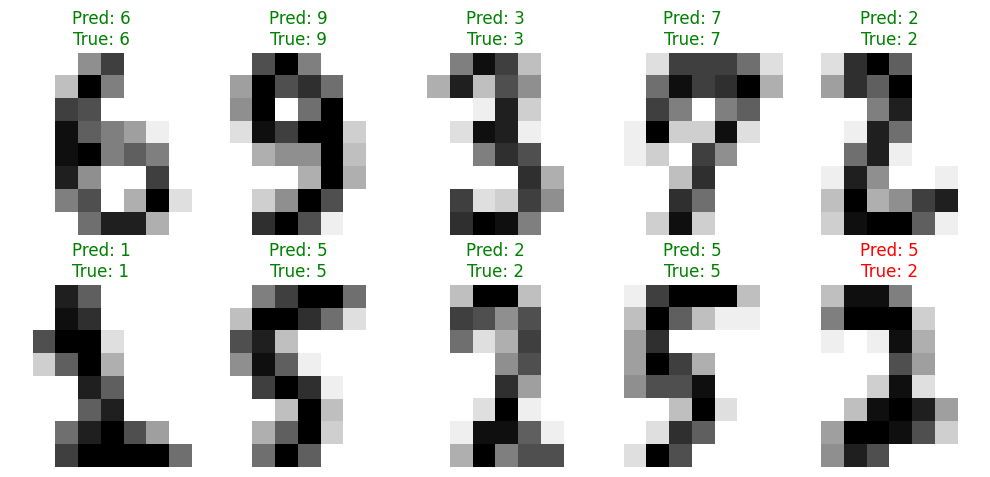

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(model, X_test, y_test, num_samples=10):
    # 1. Run the forward pass to get probabilities for the selected samples
    probs = model.forward_only(X_test[:num_samples])
    
    # 2. Get the index of the highest probability (the predicted class)
    predictions = np.argmax(probs, axis=1)
    
    # 3. Set up a matplotlib figure
    cols = 5
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.5 * rows))
    axes = axes.flatten()
    
    for i in range(num_samples):
        # The images are stored as float32 in [0, 1]. 
        # imshow handles this automatically if we use a grayscale colormap.
        image = X_test[i]
        pred_label = predictions[i]
        true_label = y_test[i]
        
        ax = axes[i]
        # Display the 8x8 image
        ax.imshow(image, cmap='gray_r', interpolation='nearest')
        
        # Color the title green if correct, red if incorrect
        color = "green" if pred_label == true_label else "red"
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        ax.axis('off')
        
    # Hide any unused subplots
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Assuming you already ran: trained_model, test_images, test_labels = train_mnist_multiprocess(...)
plot_predictions(loaded_model, test_images, test_labels, num_samples=10)


In [35]:
#!/usr/bin/env python3
import os
import math
import numpy as np
from time import perf_counter
from sklearn.model_selection import train_test_split
from numba import cuda, njit, prange

# ============================================================
# Digits loader
# ============================================================
def get_mini_mnist_numpy():
    print("Loading mini Digits dataset...")
    data = np.load("my_digits_dataset.npz")
    X = data['images'].astype(np.float32) / 16.0 
    y = data['labels'].astype(np.int64)
    data.close()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, y_train, X_test, y_test

# ============================================================
# Numba CUDA GPU kernels
# ============================================================
@cuda.jit
def zero_array_1d(arr):
    i = cuda.grid(1)
    if i < arr.shape[0]:
        arr[i] = 0

@cuda.jit
def zero_array_2d(arr):
    i, j = cuda.grid(2)
    if i < arr.shape[0] and j < arr.shape[1]:
        arr[i, j] = 0

@cuda.jit
def zero_array_3d(arr):
    i, j, k = cuda.grid(3)
    if i < arr.shape[0] and j < arr.shape[1] and k < arr.shape[2]:
        arr[i, j, k] = 0

@cuda.jit
def conv1d_forward_batch_gpu(x_batch, W, b, out):
    b_idx, co, i = cuda.grid(3)
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape

    L_out = L - k + 1
    if b_idx < B and co < C_out and i < L_out:
        s = b[co]
        for kk in range(k):
            for dd in range(d):
                s += x_batch[b_idx, i + kk, dd] * W[co, kk, dd]
        out[b_idx, co, i] = s

@cuda.jit
def relu3d_gpu(x, out):
    b, c, i = cuda.grid(3)
    B, C, L = x.shape
    if b < B and c < C and i < L:
        v = x[b, c, i]
        out[b, c, i] = v if v > 0.0 else 0.0

@cuda.jit
def max_over_time_forward_gpu(x, pooled, argmax):
    b, c = cuda.grid(2)
    B, C, L = x.shape
    if b < B and c < C:
        m = x[b, c, 0]
        mi = 0
        for i in range(1, L):
            v = x[b, c, i]
            if v > m:
                m = v
                mi = i
        pooled[b, c] = m
        argmax[b, c] = mi

@cuda.jit
def linear_forward_batch_gpu(x, W, b, out):
    b_idx, c = cuda.grid(2)
    B, H = x.shape
    C, _ = W.shape
    if b_idx < B and c < C:
        s = b[c]
        for h in range(H):
            s += W[c, h] * x[b_idx, h]
        out[b_idx, c] = s

@cuda.jit
def softmax_batch_gpu(logits, out):
    b = cuda.grid(1)
    B, C = logits.shape
    if b < B:
        m = logits[b, 0]
        for c in range(1, C):
            v = logits[b, c]
            if v > m:
                m = v
        s = 0.0
        for c in range(C):
            v = math.exp(logits[b, c] - m)
            out[b, c] = v
            s += v
        inv = 1.0 / s
        for c in range(C):
            out[b, c] *= inv

@cuda.jit
def softmax_ce_backward_gpu(probs, labels, dlogits):
    b = cuda.grid(1)
    B, C = probs.shape
    if b < B:
        for c in range(C):
            g = probs[b, c]
            if c == labels[b]:
                g -= 1.0
            # Dividing by B here handles the mean gradient across the batch
            dlogits[b, c] = g / B

@cuda.jit
def linear_backward_batch_gpu(dout, x, W, dx, dW, db):
    b_idx, c = cuda.grid(2)
    B, C = dout.shape
    _, H = W.shape

    if b_idx < B and c < C:
        g = dout[b_idx, c]
        cuda.atomic.add(db, c, g)
        for h in range(H):
            cuda.atomic.add(dW, (c, h), g * x[b_idx, h])
            cuda.atomic.add(dx, (b_idx, h), g * W[c, h])

@cuda.jit
def pool_backward_gpu(dpooled, argmax, dx):
    b, c = cuda.grid(2)
    B, C = dpooled.shape
    _, _, L = dx.shape
    if b < B and c < C:
        idx = argmax[b, c]
        if 0 <= idx < L:
            dx[b, c, idx] = dpooled[b, c]

@cuda.jit
def relu_backward_gpu(dout, x_preact, dx):
    b, c, i = cuda.grid(3)
    B, C, L = x_preact.shape
    if b < B and c < C and i < L:
        dx[b, c, i] = dout[b, c, i] if x_preact[b, c, i] > 0.0 else 0.0

@cuda.jit
def conv1d_backward_batch_gpu(dout, x_batch, W, dx, dW, db):
    b_idx, co, i = cuda.grid(3)
    B, L, d = x_batch.shape
    C_out, k, _ = W.shape

    L_out = L - k + 1
    if b_idx < B and co < C_out and i < L_out:
        g = dout[b_idx, co, i]
        cuda.atomic.add(db, co, g)
        for kk in range(k):
            for dd in range(d):
                cuda.atomic.add(dW, (co, kk, dd), g * x_batch[b_idx, i + kk, dd])

# ============================================================
# CPU Metrics
# ============================================================
@njit(parallel=True)
def accuracy_numba(probs, labels):
    B = probs.shape[0]
    correct = 0
    for i in prange(B):
        m = 0
        mv = probs[i, 0]
        for c in range(1, probs.shape[1]):
            if probs[i, c] > mv:
                mv = probs[i, c]
                m = c
        if m == labels[i]:
            correct += 1
    return correct / B

# ============================================================
# Main Class & Loop
# ============================================================
class TextCNNNumbaGPU:
    def __init__(self, embed_dim, num_filters=8, kernel_size=3, num_classes=10, seed=42):
        rng = np.random.default_rng(seed)
        scale_conv = np.sqrt(2.0 / (kernel_size * embed_dim))
        self.W_conv = (rng.standard_normal((num_filters, kernel_size, embed_dim)) * scale_conv).astype(np.float32)
        self.b_conv = np.zeros(num_filters, dtype=np.float32)

        scale_lin = np.sqrt(2.0 / num_filters)
        self.W_lin = (rng.standard_normal((num_classes, num_filters)) * scale_lin).astype(np.float32)
        self.b_lin = np.zeros(num_classes, dtype=np.float32)

    def forward_only(self, X_host, batch_size=256):
        N, L, d = X_host.shape
        C_out = self.W_conv.shape[0]
        C = self.b_lin.shape[0]
        probs_all = np.zeros((N, C), dtype=np.float32)

        Wc_d = cuda.to_device(self.W_conv)
        bc_d = cuda.to_device(self.b_conv)
        Wl_d = cuda.to_device(self.W_lin)
        bl_d = cuda.to_device(self.b_lin)

        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            Xb = X_host[s:e]
            B = Xb.shape[0]
            X_d = cuda.to_device(Xb)
            
            L_out = L - self.W_conv.shape[1] + 1
            conv_z_d = cuda.device_array((B, C_out, L_out), np.float32)
            relu_d = cuda.device_array_like(conv_z_d)
            pooled_d = cuda.device_array((B, C_out), np.float32)
            argmax_d = cuda.device_array((B, C_out), np.int64)
            logits_d = cuda.device_array((B, C), np.float32)
            probs_d = cuda.device_array((B, C), np.float32)

            threads3 = (8, 8, 8)
            blocks3 = ((B + threads3[0] - 1) // threads3[0],
                       (C_out + threads3[1] - 1) // threads3[1],
                       (L_out + threads3[2] - 1) // threads3[2])
                       
            conv1d_forward_batch_gpu[blocks3, threads3](X_d, Wc_d, bc_d, conv_z_d)
            relu3d_gpu[blocks3, threads3](conv_z_d, relu_d)

            threads2 = (16, 16)
            blocks2 = ((B + threads2[0] - 1) // threads2[0],
                       (C_out + threads2[1] - 1) // threads2[1])
            max_over_time_forward_gpu[blocks2, threads2](relu_d, pooled_d, argmax_d)

            threads2_lin = (16, 16)
            blocks2_lin = ((B + threads2_lin[0] - 1) // threads2_lin[0],
                           (C + threads2_lin[1] - 1) // threads2_lin[1])
            linear_forward_batch_gpu[blocks2_lin, threads2_lin](pooled_d, Wl_d, bl_d, logits_d)

            threads1 = 256
            blocks1 = (B + threads1 - 1) // threads1
            softmax_batch_gpu[blocks1, threads1](logits_d, probs_d)

            probs_all[s:e] = probs_d.copy_to_host()
            
        return probs_all

    def save(self, filepath):
        """Save the model's weights to a .npz file."""
        np.savez(filepath, 
                 W_conv=self.W_conv, 
                 b_conv=self.b_conv, 
                 W_lin=self.W_lin, 
                 b_lin=self.b_lin)
        print(f"Model weights saved to {filepath}")

    def load(self, filepath):
        """Load weights from a .npz file into the model."""
        data = np.load(filepath)
        self.W_conv = data['W_conv']
        self.b_conv = data['b_conv']
        self.W_lin  = data['W_lin']
        self.b_lin  = data['b_lin']
        data.close()
        print(f"Model weights loaded from {filepath}")


def train_mnist_numba_gpu(epochs=10, batch_size=128, lr=0.1):
    X_train, y_train, X_test, y_test = get_mini_mnist_numpy()
    embed_dim = X_train.shape[2]
    model = TextCNNNumbaGPU(embed_dim=embed_dim, num_filters=32, kernel_size=3, num_classes=10)

    print("=" * 80)
    print(f"Mini Digits Numba-CUDA Training | epochs={epochs}, batch_size={batch_size}, lr={lr}")
    print("=" * 80)

    rng = np.random.default_rng(42)
    N = X_train.shape[0]
    t_train_start = perf_counter()

    for epoch in range(epochs):
        idx = rng.permutation(N)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        epoch_loss = 0.0
        n_samples = 0
        t0 = perf_counter()

        for s in range(0, N, batch_size):
            e = min(N, s + batch_size)
            Xb = X_shuffled[s:e]
            yb = y_shuffled[s:e]
            B = Xb.shape[0]
            L = Xb.shape[1]
            num_filters = model.W_conv.shape[0]
            k = model.W_conv.shape[1]
            C = model.W_lin.shape[0]

            X_d = cuda.to_device(Xb)
            y_d = cuda.to_device(yb)
            Wc_d = cuda.to_device(model.W_conv)
            bc_d = cuda.to_device(model.b_conv)
            Wl_d = cuda.to_device(model.W_lin)
            bl_d = cuda.to_device(model.b_lin)

            L_out = L - k + 1
            conv_z_d = cuda.device_array((B, num_filters, L_out), np.float32)
            relu_d = cuda.device_array_like(conv_z_d)
            pooled_d = cuda.device_array((B, num_filters), np.float32)
            argmax_d = cuda.device_array((B, num_filters), np.int64)
            logits_d = cuda.device_array((B, C), np.float32)
            probs_d = cuda.device_array((B, C), np.float32)
            
            dlogits_d = cuda.device_array((B, C), np.float32)
            dpooled_d = cuda.device_array((B, num_filters), np.float32)
            dWl_d = cuda.device_array_like(Wl_d)
            dbl_d = cuda.device_array_like(bl_d)
            drelu_d = cuda.device_array_like(relu_d)
            dconv_z_d = cuda.device_array_like(conv_z_d)
            dWc_d = cuda.device_array_like(Wc_d)
            dbc_d = cuda.device_array_like(bc_d)
            
            # --- Initialize uninitialized memory ---
            zero_array_2d[((B + 15)//16, (num_filters + 15)//16), (16, 16)](dpooled_d)
            zero_array_3d[((B + 7)//8, (num_filters + 7)//8, (L_out + 7)//8), (8, 8, 8)](drelu_d)
            zero_array_3d[((B + 7)//8, (num_filters + 7)//8, (L_out + 7)//8), (8, 8, 8)](dconv_z_d)
            zero_array_2d[((C + 15)//16, (num_filters + 15)//16), (16, 16)](dWl_d)
            zero_array_1d[(C + 255)//256, 256](dbl_d)
            zero_array_3d[((num_filters + 7)//8, (k + 7)//8, (embed_dim + 7)//8), (8, 8, 8)](dWc_d)
            zero_array_1d[(num_filters + 255)//256, 256](dbc_d)

            # ================= Forward =================
            threads3 = (8, 8, 8)
            blocks3 = ((B + threads3[0] - 1) // threads3[0],
                       (num_filters + threads3[1] - 1) // threads3[1],
                       (L_out + threads3[2] - 1) // threads3[2])
            conv1d_forward_batch_gpu[blocks3, threads3](X_d, Wc_d, bc_d, conv_z_d)
            relu3d_gpu[blocks3, threads3](conv_z_d, relu_d)

            threads2 = (16, 16)
            blocks2 = ((B + threads2[0] - 1) // threads2[0],
                       (num_filters + threads2[1] - 1) // threads2[1])
            max_over_time_forward_gpu[blocks2, threads2](relu_d, pooled_d, argmax_d)

            threads2_lin = (16, 16)
            blocks2_lin = ((B + threads2_lin[0] - 1) // threads2_lin[0],
                           (C + threads2_lin[1] - 1) // threads2_lin[1])
            linear_forward_batch_gpu[blocks2_lin, threads2_lin](pooled_d, Wl_d, bl_d, logits_d)

            threads1 = 256
            blocks1 = (B + threads1 - 1) // threads1
            softmax_batch_gpu[blocks1, threads1](logits_d, probs_d)

            # ================= Host Loss Calculation =================
            probs_host = probs_d.copy_to_host()
            eps = 1e-9
            loss = -np.sum(np.log(probs_host[np.arange(B), yb] + eps))
            epoch_loss += loss
            n_samples += B

            # ================= Backward =================
            softmax_ce_backward_gpu[blocks1, threads1](probs_d, y_d, dlogits_d)

            linear_backward_batch_gpu[blocks2_lin, threads2_lin](dlogits_d, pooled_d, Wl_d,
                                                                 dpooled_d, dWl_d, dbl_d)

            pool_backward_gpu[blocks2, threads2](dpooled_d, argmax_d, drelu_d)

            relu_backward_gpu[blocks3, threads3](drelu_d, conv_z_d, dconv_z_d)

            dummy_dx = cuda.device_array((1,), dtype=np.float32)
            conv1d_backward_batch_gpu[blocks3, threads3](
                dconv_z_d, X_d, Wc_d, dummy_dx, dWc_d, dbc_d
            )

            # ================= Update weights on Host =================
            # NO DIVISION BY `B` HERE (it is handled inside softmax_ce_backward_gpu)
            model.W_conv -= lr * dWc_d.copy_to_host()
            model.b_conv -= lr * dbc_d.copy_to_host()
            model.W_lin  -= lr * dWl_d.copy_to_host()
            model.b_lin  -= lr * dbl_d.copy_to_host()

        epoch_time = perf_counter() - t0

        train_probs = model.forward_only(X_train)
        train_acc = accuracy_numba(train_probs, y_train)
        test_probs = model.forward_only(X_test)
        test_acc = accuracy_numba(test_probs, y_test)

        print(f"epoch={epoch+1}/{epochs} | loss={epoch_loss/n_samples:.4f} | "
              f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f} | epoch_time={epoch_time:.2f}s")
        
    print(f"\ntotal train time = {perf_counter() - t_train_start:.3f} s")
    return model, X_test, y_test

if __name__ == "__main__":
    trained_model, test_images, test_labels = train_mnist_numba_gpu(
        epochs=200, batch_size=128, lr=0.05
    )
    
    # 1. Save the model after training
    trained_model.save("my_mini_digits_cnn_gpu.npz")

    # 2. Initialize a fresh model later (same architecture)
    # Note: embed_dim = test_images.shape[2]
    loaded_model = TextCNNNumbaGPU(
        embed_dim=test_images.shape[2], 
        num_filters=512, 
        kernel_size=32, 
        num_classes=10
    )

    # 3. Load the saved weights (overwriting random initialization)
    loaded_model.load("my_mini_digits_cnn_gpu.npz")

    # 4. Predict exactly as before using the GPU forward pass
    print("\n--- Example Prediction ---")
    probs = loaded_model.forward_only(test_images[:5])
    predictions = np.argmax(probs, axis=1)
    
    print("Predicted from loaded model:", predictions)
    print("Actual                     :", test_labels[:5])


Loading mini Digits dataset...
Mini Digits Numba-CUDA Training | epochs=200, batch_size=128, lr=0.05


/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/aytu/.conda/envs/huggingface/lib/python3.12/site-package

epoch=1/200 | loss=2.4101 | train_acc=0.1260 | test_acc=0.1222 | epoch_time=1.35s
epoch=2/200 | loss=2.2714 | train_acc=0.2171 | test_acc=0.2444 | epoch_time=0.05s
epoch=3/200 | loss=2.2030 | train_acc=0.2867 | test_acc=0.2972 | epoch_time=0.06s
epoch=4/200 | loss=2.1455 | train_acc=0.3417 | test_acc=0.3611 | epoch_time=0.10s
epoch=5/200 | loss=2.0864 | train_acc=0.3869 | test_acc=0.4278 | epoch_time=0.06s
epoch=6/200 | loss=2.0330 | train_acc=0.4384 | test_acc=0.4389 | epoch_time=0.05s
epoch=7/200 | loss=1.9789 | train_acc=0.4746 | test_acc=0.4778 | epoch_time=0.07s
epoch=8/200 | loss=1.9251 | train_acc=0.5191 | test_acc=0.5333 | epoch_time=0.05s
epoch=9/200 | loss=1.8722 | train_acc=0.5505 | test_acc=0.5556 | epoch_time=0.06s
epoch=10/200 | loss=1.8198 | train_acc=0.5769 | test_acc=0.5778 | epoch_time=0.05s
epoch=11/200 | loss=1.7678 | train_acc=0.6054 | test_acc=0.6000 | epoch_time=0.05s
epoch=12/200 | loss=1.7134 | train_acc=0.6305 | test_acc=0.6389 | epoch_time=0.05s
epoch=13/200 

/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/home/aytu/.conda/envs/huggingface/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


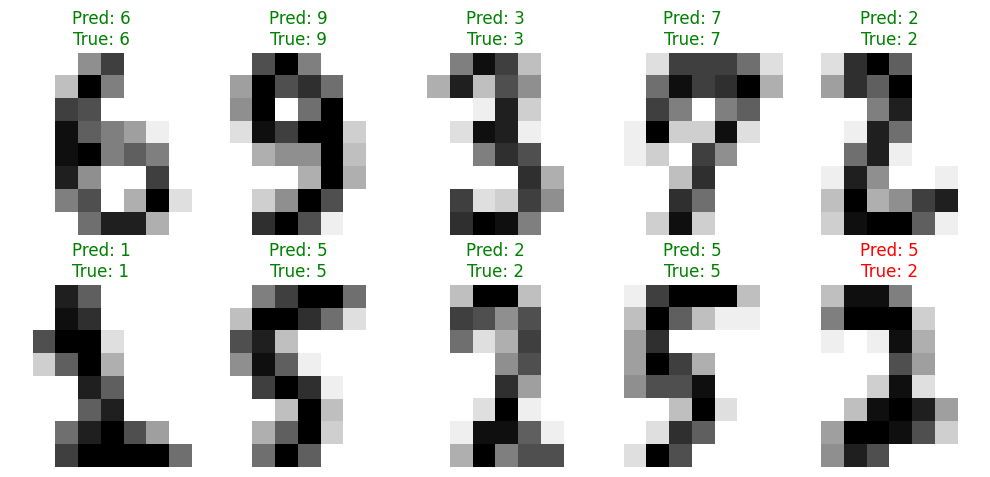

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(model, X_test, y_test, num_samples=10):
    # 1. Run the forward pass to get probabilities for the selected samples
    probs = model.forward_only(X_test[:num_samples])
    
    # 2. Get the index of the highest probability (the predicted class)
    predictions = np.argmax(probs, axis=1)
    
    # 3. Set up a matplotlib figure
    cols = 5
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.5 * rows))
    axes = axes.flatten()
    
    for i in range(num_samples):
        # The images are stored as float32 in [0, 1]. 
        # imshow handles this automatically if we use a grayscale colormap.
        image = X_test[i]
        pred_label = predictions[i]
        true_label = y_test[i]
        
        ax = axes[i]
        # Display the 8x8 image
        ax.imshow(image, cmap='gray_r', interpolation='nearest')
        
        # Color the title green if correct, red if incorrect
        color = "green" if pred_label == true_label else "red"
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        ax.axis('off')
        
    # Hide any unused subplots
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Assuming you already ran: trained_model, test_images, test_labels = train_mnist_multiprocess(...)
plot_predictions(loaded_model, test_images, test_labels, num_samples=10)


In [24]:
# Assuming your training loop just finished:
test_acc = calculate_accuracy(trained_model, test_images, test_labels)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%")


Final Test Accuracy: 95.56%
